In [1]:
# Read all files in folder, each file should be extracted the correct name to it. 
# If full file name is eval_1000steps_pylon_socket_x_-2deg_prosthesis_body_orientation.pkl get x_-2deg as name 

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update('jax_platform_name', 'cpu')

import re
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

import loco_mujoco.evaluation.evaluation_prosthesis as eval_pros
postprocess_handler = eval_pros.PostProcessMetricsHandler()

import importlib



/home/nadinebadie/anaconda3/envs/loco-mujoco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only read joint data from file
with open("/home/nadinebadie/loco-mujoco/prosthesis_evaluation/joint_data_walk_SkeletonMuscle.pkl", "rb") as f:
    joint_data_baseline = pickle.load(f)


In [11]:
folder_name = "/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-24/04-30-21/checkpoints_seed2/20260125_013533_ckpt_199884800_pylon_socket_ori_x"

#"/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-23/17-33-34/checkpoints_seed1/20260125_013452_ckpt_199884800_pylon_socket_ori_x"
#"/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-19/14-52-36/checkpoints/20260119_193439_pylon_socket_pos_x"
#"/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260115_093951_pylon_socket_pos_x_TalZ5/"
# RERUN-REEVAL '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-12/21-23-37/checkpoints/20260113_141419_talus_ori_z_ckpt_299827200'

#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-12/21-23-37/checkpoints/20260113_114022_pylon_socket_pos_z_ckpt_299827200'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-12/21-23-37/checkpoints/20260113_124751_pylon_socket_ori_x_ckpt_299827200'


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-09/08-47-22/checkpoints/20260109_193919_pylon_socket_ori_z_ckpt_199884800'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-09/08-47-22/checkpoints/20260109_193813_pylon_socket_ori_x_ckpt_199884800'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-09/08-47-22/20260109_144401_pylon_socket_ori_x'
# "/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-09/08-47-22/20260109_144439_pylon_socket_pos_z"

# "/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/checkpoints/20260109_122107_pylon_socket_pos_x_ckpt_399769600/"
# "/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/checkpoints/20260108_225617_pylon_socket_ori_x_ckpt_399769600/"
# "/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/checkpoints/20260108_225635_pylon_socket_ori_z_ckpt_399769600/"
# "/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/checkpoints/20260108_214511_pylon_socket_pos_z_ckpt_399769600/"


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-08/12-51-16/checkpoints/20260108_211630_pylon_socket_ori_z_ckpt_99942400'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-08/12-51-16/checkpoints/20260108_174430_pylon_socket_pos_z_ckpt_99942400'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-08/12-51-16/checkpoints/20260108_174459_pylon_socket_ori_x_ckpt_99942400'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-08/12-51-16/checkpoints/20260108_174408_pylon_socket_pos_x_ckpt_99942400'



#"/media/calc_2/loco-mujoco_results/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260109_122323_talus_ori_z/"
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260108_125906_pylon_socket_pos_x_2cm'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260108_104444_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260108_104530_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260108_104509_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-07/22-13-29/20260108_104421_pylon_socket_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-06/16-46-48/checkpoints/20260107_154151_pylon_socket_pos_x_ckpt_299827200'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-06/16-46-48/checkpoints/20260107_093638_pylon_socket_ori_z_ckpt_299827200'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-06/16-46-48/checkpoints/20260107_093709_pylon_socket_pos_z_ckpt_299827200'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-06/16-46-48/checkpoints/20260107_093621_pylon_socket_ori_x_ckpt_299827200'


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_132158_pylon_socket_pos_x_ckpt_299827200'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_115841_pylon_socket_pos_z_ckpt_299827200'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_115803_pylon_socket_ori_z_ckpt_299827200'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_114139_pylon_socket_ori_x_ckpt_299827200'

#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_093205_pylon_socket_ori_x_ckpt_199884800'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_093117_pylon_socket_pos_x_ckpt_199884800'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_093050_pylon_socket_pos_z_ckpt_199884800'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-05/11-41-34/checkpoints/20260106_093257_pylon_socket_ori_z_ckpt_199884800'

#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-02/20-09-00/checkpoints/20260105_111738_pylon_socket_pos_z'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2026-01-02/20-09-00/checkpoints/20260105_111635_pylon_socket_ori_x'


#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-30/14-24-58/20251201_144219_talus_ori_z_test_knee_lim'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-30/14-24-58/20251201_144044_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-28/20-47-01/20251129_104714_pylon_socket_ori_x'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-28/20-47-01/20251129_104640_pylon_socket_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/18-39-15/20251126_132937_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_212231_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_201102_pylon_socket_ori_x'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_201043_pylon_socket_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/23-09-51/20251126_181956_talus_ori_z_3000steps'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/18-39-15/20251126_181929_talus_ori_z_3000steps'


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_192544_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_192612_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_201043_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/14-38-24/20251127_201102_pylon_socket_ori_x'


#### 3 spheres Scone 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/02-42-57/20251127_100219_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/02-42-57/20251127_103445_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/02-42-57/20251127_124913_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-27/02-42-57/20251127_124934_pylon_socket_pos_x'



# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/09-23-44/20251125_145759_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/09-23-44/20251125_140929_pylon_socket_pos_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/09-23-44/20251125_140916_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/09-23-44/20251125_132811_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-25/09-23-44/20251125_132747_pylon_socket_ori_x'



# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-24/21-02-34/20251125_113140_talus_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-24/21-02-34/20251125_104826_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-24/21-02-34/20251125_104802_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-24/21-02-34/20251125_100635_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-24/21-02-34/20251125_100613_pylon_socket_pos_z'

#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-23/00-13-51/20251123_151048_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-23/00-13-51/20251123_151133_pylon_socket_ori_x'


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-23/00-13-51/20251123_151048_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-21/13-38-28/20251122_112045_talus_ori_z'


#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-05/12-39-50/20251106_114050_pylon_socket_pos_z'

# P1 ContSphere3 SocketTxTz
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-05/12-39-50/20251106_114050_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-05/12-39-50/20251106_114007_pylon_socket_ori_x'


# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_180240_pylon_socket_pos_x'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_180254_pylon_socket_pos_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_173103_talus_ori_z'



### Sphere Scone Exact Solref 800, 300
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_154350_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_154412_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_164741_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_164754_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-19/10-35-32/20251119_164754_pylon_socket_pos_x'



# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_135003_pylon_socket_ori_z_TalZ-5'




# Cylinder Heel and Toe Sphere solref_org
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_101401_pylon_socket_ori_x'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_095115_talus_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_101426_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_113026_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_113039_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_121650_pylon_socket_pos_z_TalZ5°' 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_121637_pylon_socket_pos_x_TalZ5°'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_130254_pylon_socket_pos_z_TalZ-5'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_130307_pylon_socket_pos_x_TalZ-5'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_141415_pylon_socket_ori_x_TalZ-5'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_135003_pylon_socket_ori_z_TalZ-5'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_152109_pylon_socket_ori_x_TalZ5'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/19-39-33/20251117_161756_pylon_socket_ori_z_TalZ5'



# SphereScone solref_org 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_125129_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_122901_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_141005_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_150437_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_150912_pylon_socket_ori_z_talus_z5deg'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_213801_pylon_socket_ori_x_talus_z-5deg'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_213916_pylon_socket_ori_z_talus_z-5deg'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_225435_pylon_socket_pos_x_talus_z5deg'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251116_232043_pylon_socket_pos_x_talus_z-5deg'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-16/07-24-10/20251117_090254_pylon_socket_pos_z_talus_z-5deg'



# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_212135_talus_ori_z'



# Cylinder Heel and Toe Sphere 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_193345_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_193404_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_203252_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_203319_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/16-05-15/20251115_212135_talus_ori_z'


# 2 Spheres Tip Toe 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-12/15-54-55/20251115_155100_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-12/15-54-55/20251115_141532_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-12/15-54-55/20251115_170327_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-12/15-54-55/20251115_182406_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-12/15-54-55/20251115_134645_talus_ori_z'




# SPHERE SCONE 
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/03-51-01/20251115_135114_pylon_socket_ori_x'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/03-51-01/20251115_144646_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/03-51-01/20251115_155135_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/03-51-01/20251115_170415_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-13/03-51-01/20251115_132222_talus_ori_z'

# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-11/06-30-02/20251111_120109_pylon_socket_pos_x'


# 3 spheres Phase 2 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-11/06-30-02/20251111_110931_pylon_socket_pos_z'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-11-11/06-30-02/20251111_110859_pylon_socket_ori_x'


#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-19/01-21-16/20251020_125422_cylinder_pylon_socket_pos_z'


# 6dof socket joint slack training with randomization no knee limit 
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-10/03-26-00/20251010_102730_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-10/03-26-00/20251010_102837_pylon_socket_ori_z'


# 6dof socket joint slack training without randomization 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-05/06-29-27/20251006_230947_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-05/06-29-27/20251007_001228_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-05/06-29-27/20251007_154758_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-05/06-29-27/20251007_154632_pylon_socket_ori_z'


# Amputation Height 0.1 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/21-43-53/20251005_211613_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/21-43-53/20251005_211538_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/21-43-53/20251006_001008_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/21-43-53/20251006_001036_pylon_socket_pos_x'

# Amputation Height 0.3 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/08-10-51/20251005_211423_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/08-10-51/20251005_211457_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/08-10-51/20251005_230513_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-20/08-10-51/20251006_001049_pylon_socket_pos_x'


# Limited Hip rotation and adduction 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20251001_115256_pylon_socket_pos_z_withoutHipRotAdd_AllFall'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20251001_115211_pylon_socket_ori_x_withoutHipRotAdd_AllFall'
### Retrained limited hip rotation and adduction 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/08-28-31/20251002_123606_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/08-28-31/20251002_141136_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/08-28-31/20251002_151325_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-10-02/08-28-31/20251002_141150_pylon_socket_ori_z'


# Without socket joint 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20250929_160511_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20250929_160542_pylon_socket_ori_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20250929_141507_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-29/09-28-36/20250929_141808_pylon_socket_pos_z'

# Without socket ty joint 
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-19/15-06-22/20250928_113225_pylon_socket_pos_z'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-19/15-06-22/20250928_113139_pylon_socket_ori_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-19/15-06-22/20250928_113236_pylon_socket_pos_x'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-09-19/15-06-22/20250928_192600_pylon_socket_ori_z'



# With socket ty (6 dof)
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162948_pylon_socket_pos_x'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162915_pylon_socket_ori_z'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162948_pylon_socket_pos_x'
#'/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20250923_162834_pylon_socket_ori_x'
## Without socket ty slack (not retrained) (6dof)
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20251002_141928_pylon_socket_ori_z_woSlack'
# '/home/nadinebadie/loco-mujoco/prosthesis_rand_save/outputs/2025-08-27/09-05-19/20251002_142153_pylon_socket_pos_x_woSlack'



all_loaded_data = {}

for fname in os.listdir(folder_name):
    if fname.endswith(".pkl"):
        # Extract the correct name using regex
        # match = re.search(r'eval_3000steps_pylon_socket_(.*?)_prosthesis_body_(?:orientation|position)\.pkl', fname)
        # match = re.search(r'eval_2000steps_talus_(.*?)_prosthesis_body_(?:orientation|position)\.pkl', fname)
        match = re.search(r'eval_2000steps_pylon_socket_(.*?)_prosthesis_body_(?:orientation|position)_\d+seed\.pkl', fname)
        if not match:
            continue
        extracted_name = match.group(1)
        file_path = os.path.join(folder_name, fname)
        with open(file_path, "rb") as f:
            loaded_data = pickle.load(f)
            all_loaded_data[extracted_name] = loaded_data
            print(f"Loaded data for {extracted_name}: {loaded_data.keys()}")


Loaded data for x_-6deg: dict_keys(['total_steps', 'n_envs', 'all_grf_l', 'all_grf_r', 'all_foot_ground_contact_left', 'all_foot_ground_contact_right', 'all_sensor_force', 'sensor_force_names', 'sum_step_activations', 'step_norm_activations', 'sum_muscles_activations', 'step_muscles_norm_activations', 'step_num_norm_activations', 'evaluation_muscle_groups', 'evaluation_joint_names', 'evaluation_muscle_names', 'all_actions', 'all_actuator_names', 'all_body_poses', 'evaluation_body_names', 'root_angle', 'root_velocity', 'root_forces_constraint', 'root_forces_smooth', 'root_forces_applied', 'root_torques', 'root_energy_exp', 'root_angle_per_step_left', 'root_angle_per_step_right', 'root_velocity_per_step_left', 'root_velocity_per_step_right', 'root_forces_constraint_per_step_left', 'root_forces_constraint_per_step_right', 'root_forces_smooth_per_step_left', 'root_forces_smooth_per_step_right', 'root_forces_applied_per_step_left', 'root_forces_applied_per_step_right', 'root_torques_per_ste

In [12]:
# FINAL CODE 
import loco_mujoco.evaluation.evaluation_prosthesis as eval_pros

import importlib
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

# Get steps from GRF instead of Contact 
min_walk_step_length_left = 30
min_walk_step_length = 40 #70 #60
run_step_data={}

for run_key, run_dict in all_loaded_data.items():
    all_grf_l = np.array(run_dict.get("all_grf_l"))
    all_grf_r = np.array(run_dict.get("all_grf_r"))
    z_grf_l = all_grf_l[:,5]
    z_grf_r = all_grf_r[:,5]

    step_start_left = postprocess_handler.get_start_steps_from_grfZ(z_grf_l, min_walk_step_length=min_walk_step_length_left)
    step_start_right = postprocess_handler.get_start_steps_from_grfZ(z_grf_r, min_walk_step_length=min_walk_step_length)
    contact_length_left = postprocess_handler.get_contact_lengths_from_grfZ(z_grf_l, min_walk_step_length=min_walk_step_length_left, threshold = 0.5)
    contact_length_right = postprocess_handler.get_contact_lengths_from_grfZ(z_grf_r, min_walk_step_length=min_walk_step_length, threshold = 0.5)
    all_contact_left = postprocess_handler.get_contact_from_grfZ(z_grf_l)
    all_contact_right = postprocess_handler.get_contact_from_grfZ(z_grf_r)
    # single_support_right_time, single_support_left_time = postprocess_handler.compute_single_support_time(all_contact_right, all_contact_left)
    single_support_right_time_per_step, single_support_left_time_per_step = postprocess_handler.compute_single_support_per_step(all_contact_right,all_contact_left, step_start_right, step_start_left)
    # # print('step_start_left', step_start_left)
    # print('step_start_right', step_start_right)
    # # print('contact_length_left', contact_length_left)
    # print('z_grf_r', z_grf_r)
    # print('contact_length_right', contact_length_right)
    
    run_step_data[run_key] = {
        "step_start_left": step_start_left,
        "step_start_right": step_start_right,
        "contact_length_left": contact_length_left, 
        "contact_length_right": contact_length_right, 
        "all_contact_left": all_contact_left, 
        "all_contact_right": all_contact_right, 
        # "single_support_right_time": single_support_right_time, 
        # "single_support_left_time": single_support_left_time,
        "single_support_right_per_step": single_support_right_time_per_step, 
        "single_support_left_per_step": single_support_left_time_per_step

    }

In [14]:
# Take out 1. step in right & left side for all runs in run_step_data
for run_key in run_step_data.keys():
    run_step_data[run_key]['step_start_right'] = run_step_data[run_key]['step_start_right'][1:]
    run_step_data[run_key]['step_start_left'] = run_step_data[run_key]['step_start_left'][1:]

In [ ]:
run_step_data["z_-15mm"]["step_start_right"] = run_step_data["z_-15mm"]["step_start_right"][1:]
run_step_data["z_-10mm"]["step_start_right"] = run_step_data["z_-10mm"]["step_start_right"][1:]
run_step_data["z_-5mm"]["step_start_right"] = run_step_data["z_-5mm"]["step_start_right"][1:]
run_step_data["z_0mm"]["step_start_right"] = run_step_data["z_0mm"]["step_start_right"][1:]
run_step_data["z_15mm"]["step_start_right"] = run_step_data["z_15mm"]["step_start_right"][1:]
run_step_data["z_10mm"]["step_start_right"] = run_step_data["z_10mm"]["step_start_right"][1:]
run_step_data["z_5mm"]["step_start_right"] = run_step_data["z_5mm"]["step_start_right"][1:]

run_step_data["z_-15mm"]["step_start_left"] = run_step_data["z_-15mm"]["step_start_left"][1:]
run_step_data["z_-10mm"]["step_start_left"] = run_step_data["z_-10mm"]["step_start_left"][1:]
run_step_data["z_-5mm"]["step_start_left"] = run_step_data["z_-5mm"]["step_start_left"][1:]
run_step_data["z_0mm"]["step_start_left"] = run_step_data["z_0mm"]["step_start_left"][1:]
run_step_data["z_15mm"]["step_start_left"] = run_step_data["z_15mm"]["step_start_left"][1:]
run_step_data["z_10mm"]["step_start_left"] = run_step_data["z_10mm"]["step_start_left"][1:]
run_step_data["z_5mm"]["step_start_left"] = run_step_data["z_5mm"]["step_start_left"][1:]



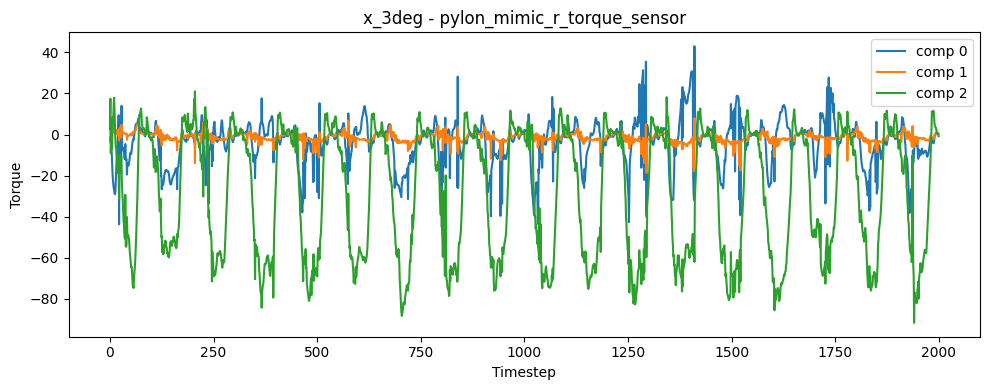

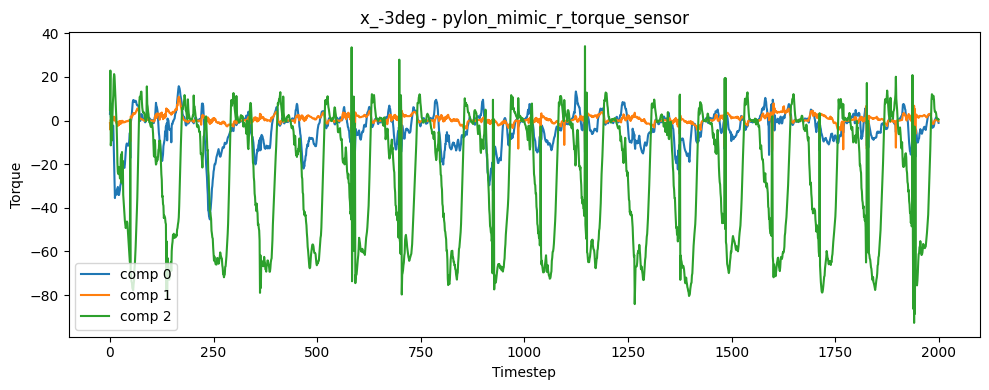

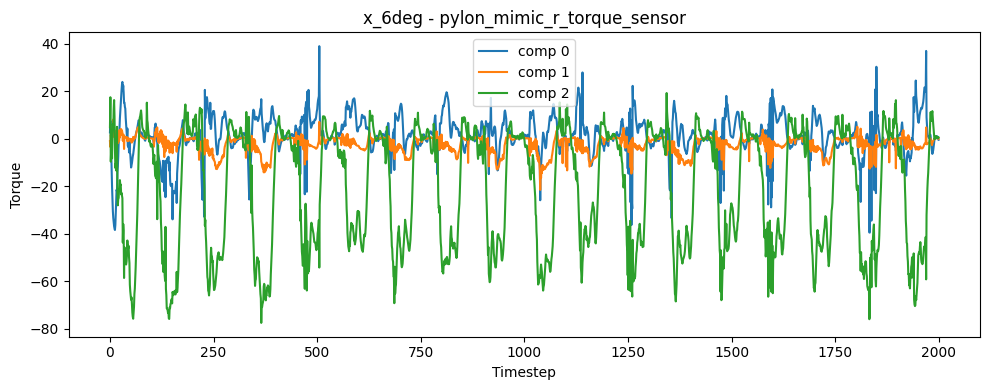

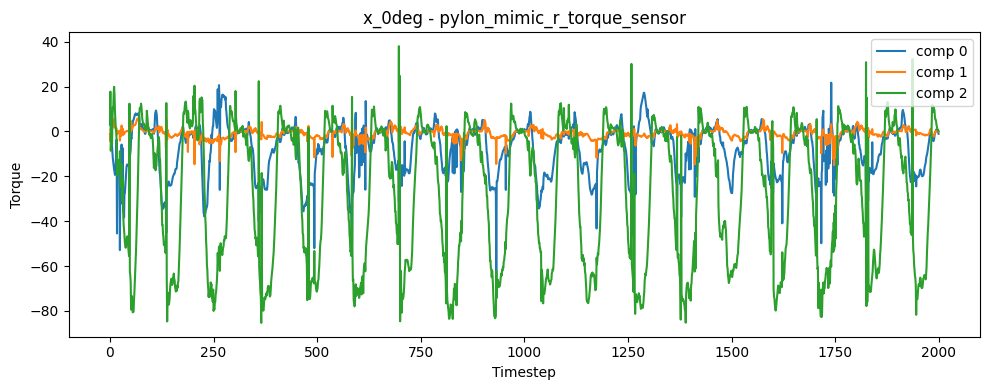

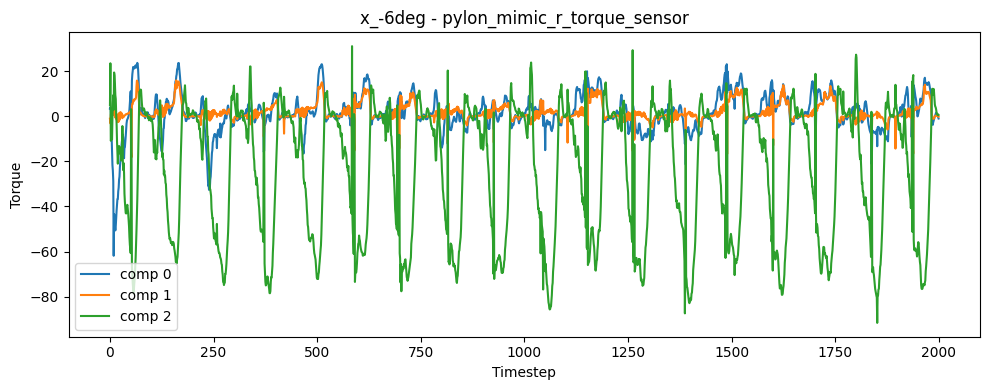

In [19]:
# plot all_sensor_force for each run key for torque and pylon in name


# Filter and plot torque/pylon sensor forces for each run
for run_key, run_dict in all_loaded_data.items():
    sensor_forces = run_dict.get("all_sensor_force", {})
    sensor_names = run_dict.get("sensor_force_names", sensor_forces.keys())
    filtered_names = [n for n in sensor_names if "torque" in n and "pylon" in n]

    for name in filtered_names:
        data = np.asarray(sensor_forces.get(name, []))
        if data.ndim < 2 or data.size == 0:
            continue

        plt.figure(figsize=(10, 4))
        for comp_idx in range(data.shape[1]):
            plt.plot(data[:, comp_idx], label=f"comp {comp_idx}")
        plt.title(f"{run_key} - {name}")
        plt.xlabel("Timestep")
        plt.ylabel("Torque")
        plt.legend()
        plt.tight_layout()
        plt.show()


step_start_left [273, 389, 504, 616, 728, 843, 950, 1068, 1177, 1291, 1402, 1512, 1625, 1745, 1854, 1967]
step_start_right [219, 331, 444, 559, 669, 787, 902, 1007, 1127, 1231, 1343, 1454, 1569, 1683, 1796, 1914]


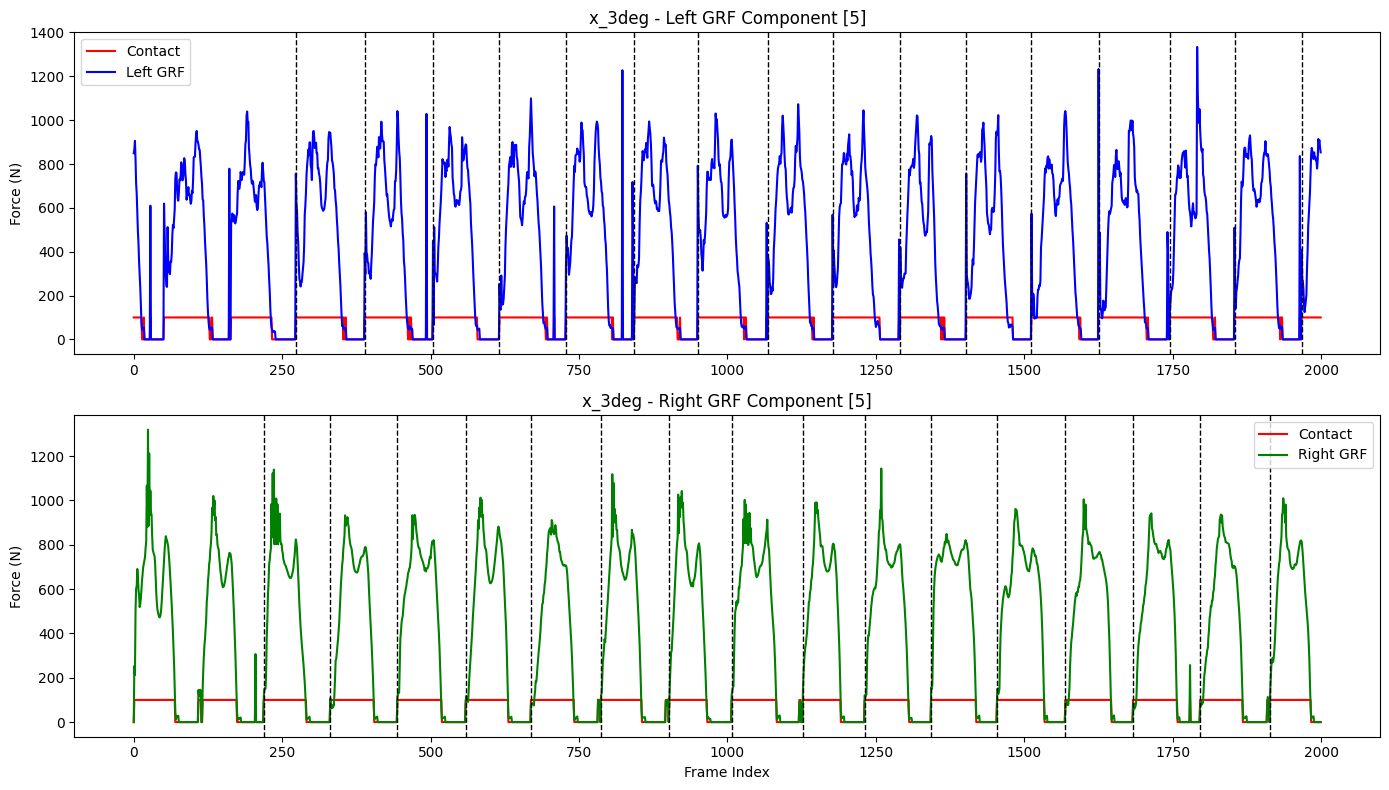

step_start_left [282, 387, 507, 622, 727, 847, 962, 1071, 1177, 1296, 1413, 1519, 1629, 1747, 1859, 1970]
step_start_right [220, 331, 446, 566, 669, 782, 896, 1010, 1121, 1233, 1345, 1459, 1571, 1686, 1797, 1912]


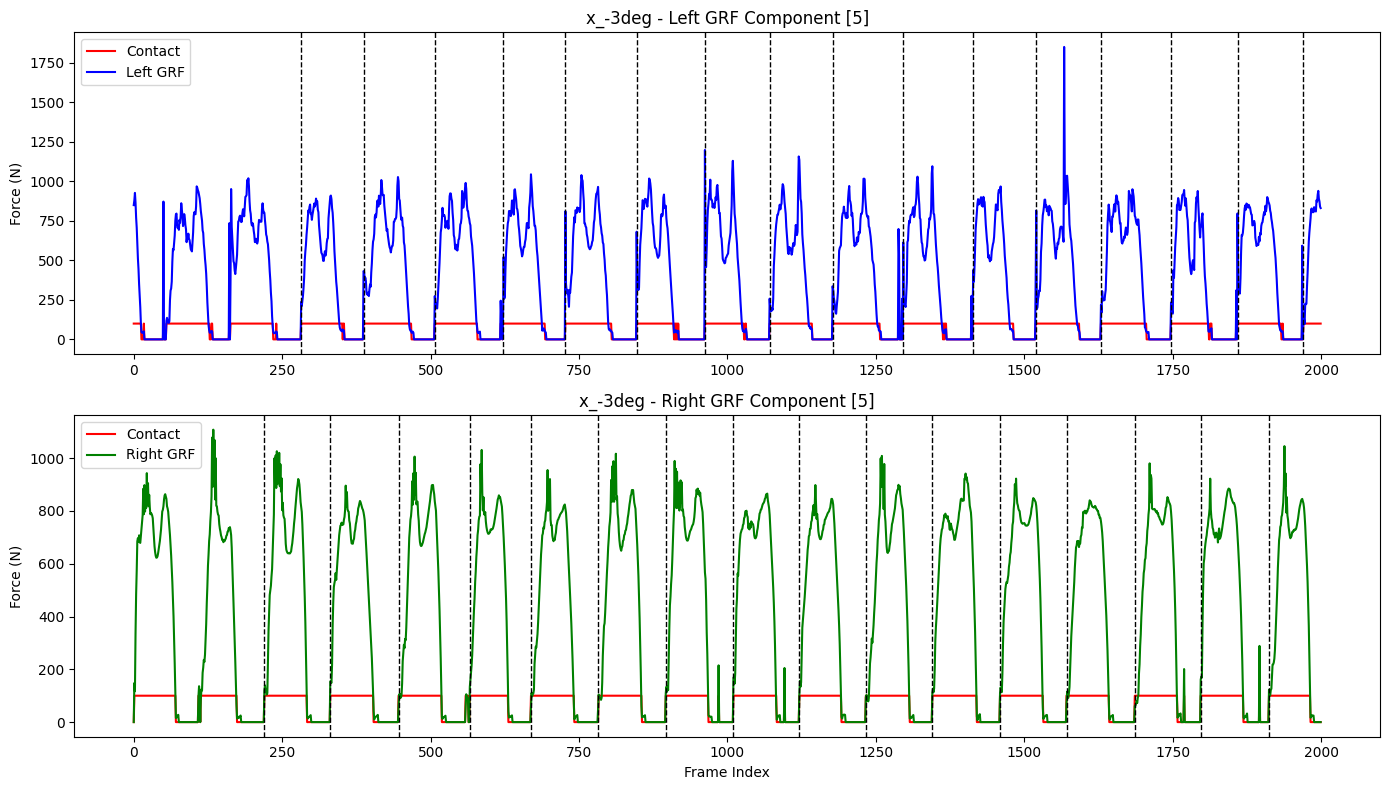

step_start_left [274, 388, 500, 615, 727, 838, 950, 1064, 1174, 1287, 1403, 1513, 1626, 1739, 1851, 1963]
step_start_right [215, 328, 445, 558, 667, 781, 895, 1016, 1123, 1232, 1342, 1456, 1574, 1681, 1796, 1908]


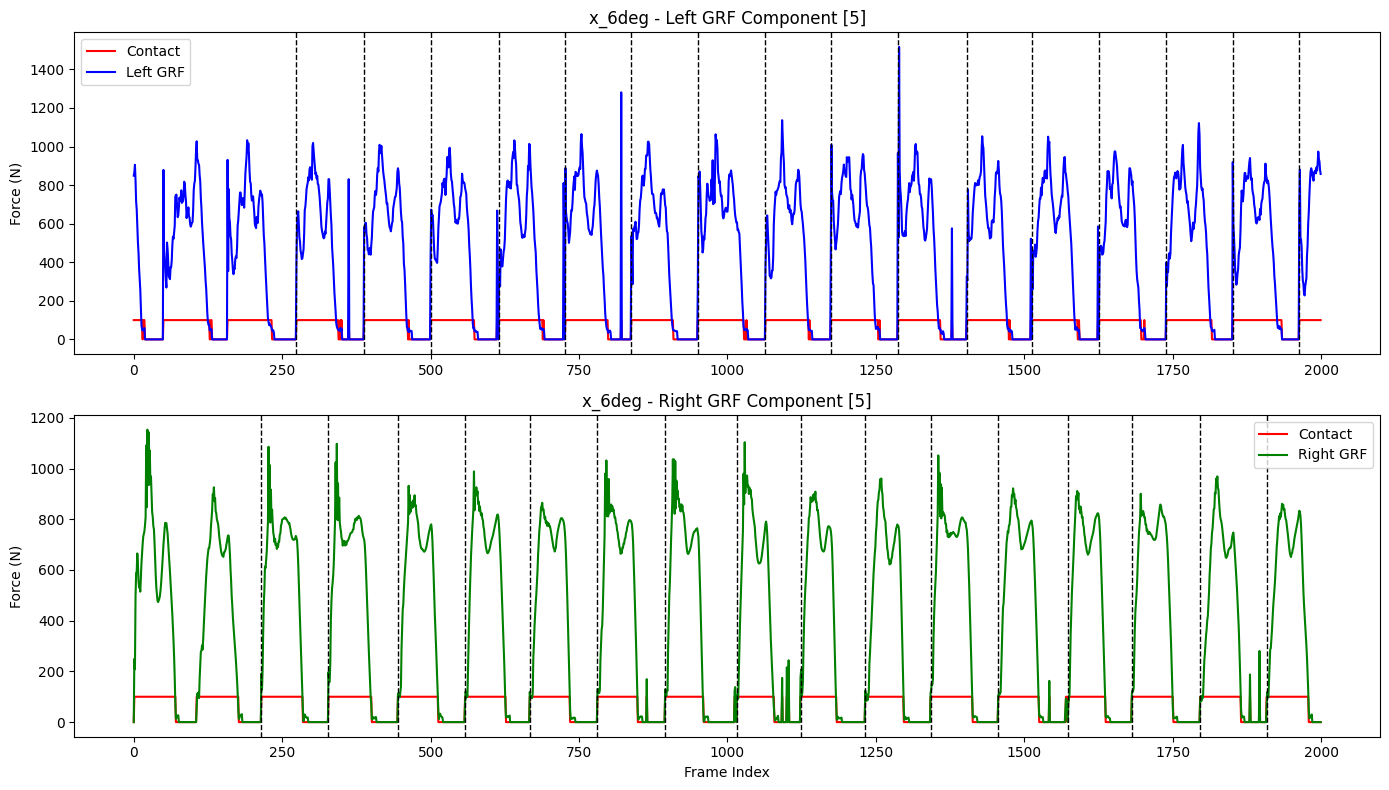

step_start_left [274, 392, 507, 624, 724, 847, 958, 1067, 1174, 1296, 1411, 1520, 1631, 1749, 1853, 1966]
step_start_right [216, 331, 444, 559, 669, 790, 902, 1010, 1119, 1231, 1346, 1468, 1575, 1683, 1795, 1910]


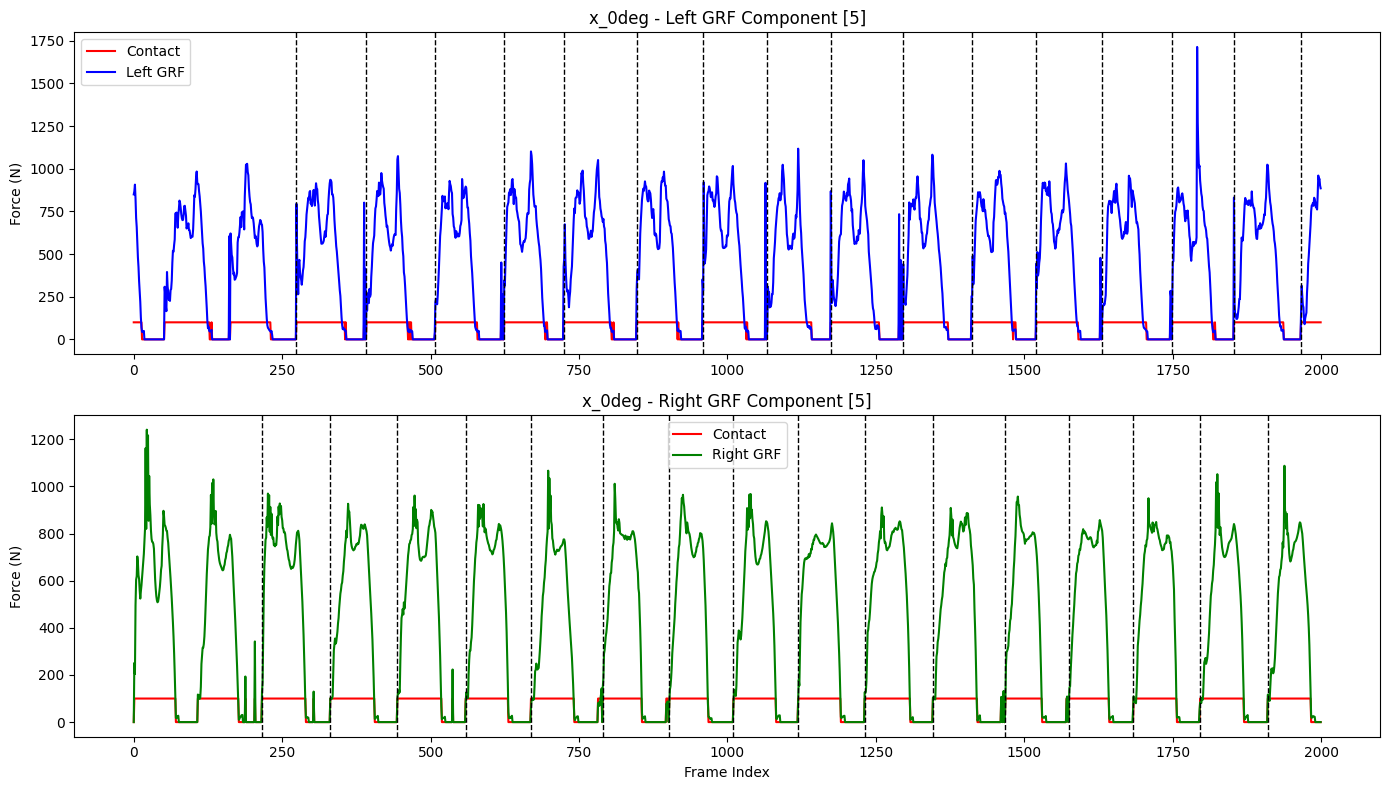

step_start_left [282, 389, 504, 616, 728, 847, 959, 1069, 1179, 1297, 1412, 1518, 1633, 1748, 1861, 1973]
step_start_right [219, 331, 447, 568, 667, 782, 897, 1008, 1123, 1230, 1345, 1460, 1570, 1684, 1793, 1910]


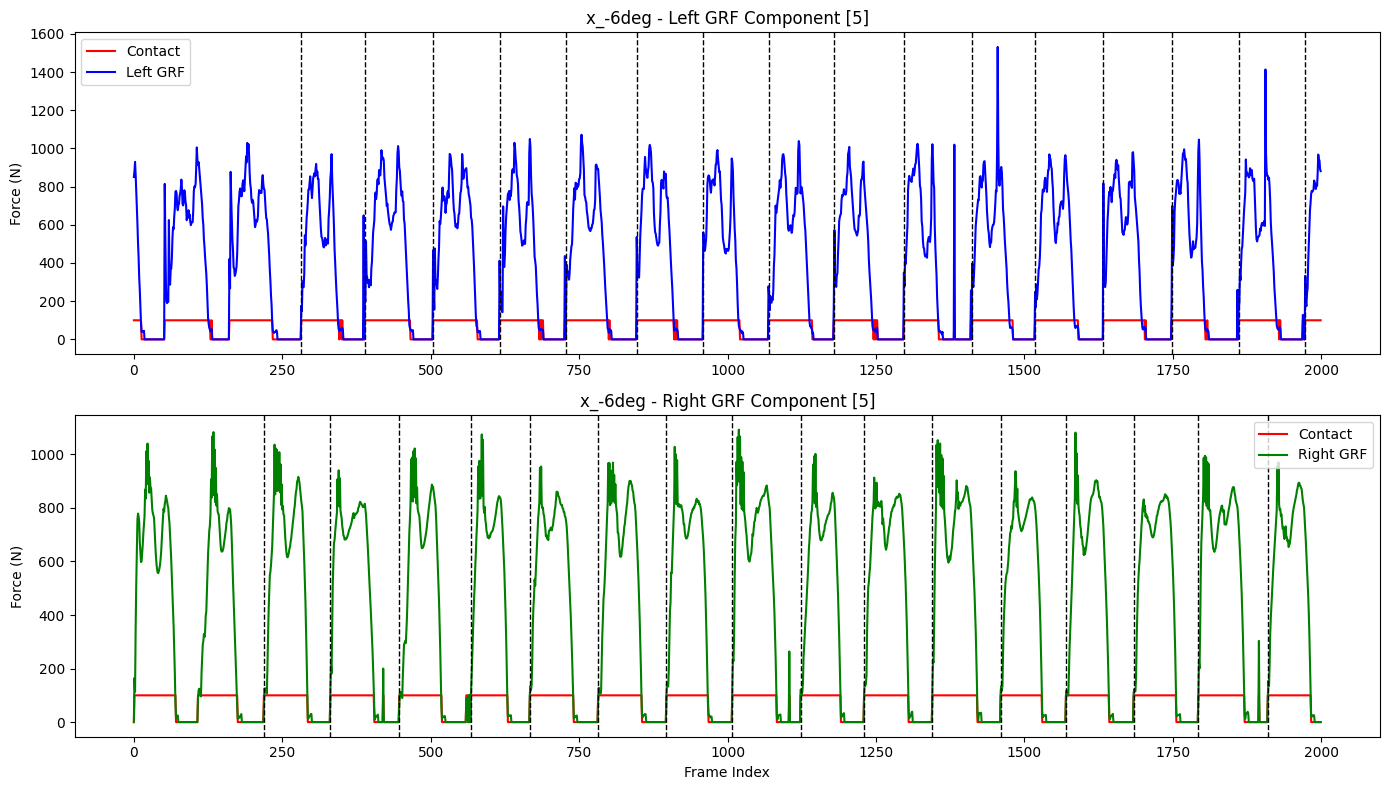

In [20]:
postprocess_handler.plot_full_grf_with_step_markers(
    all_loaded_data,
    run_step_data,
    component_index=5
)

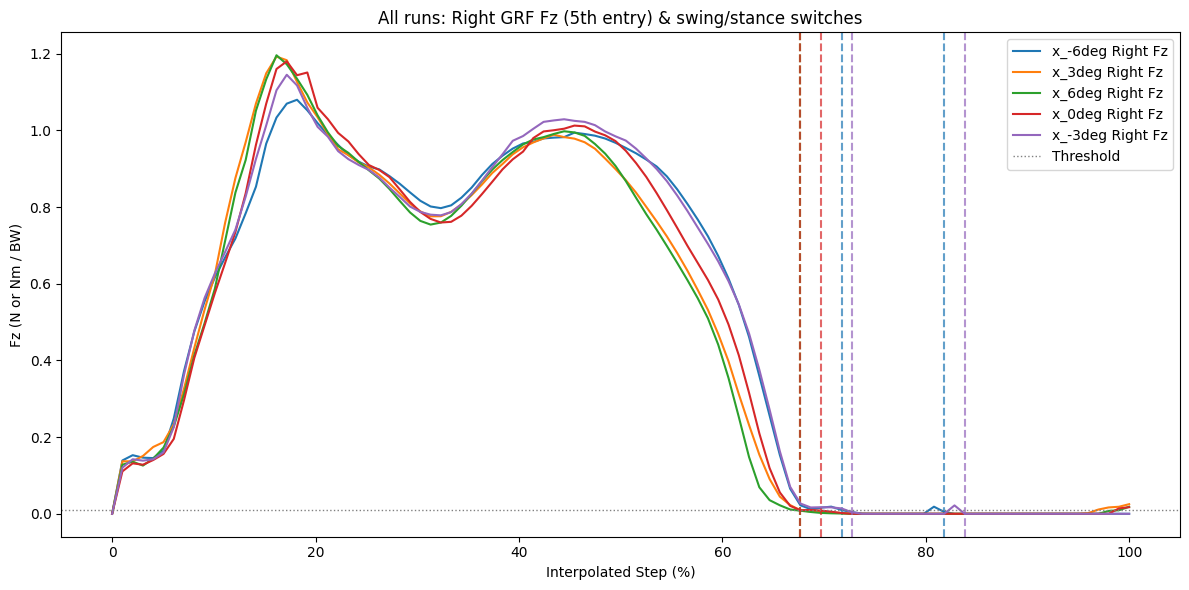

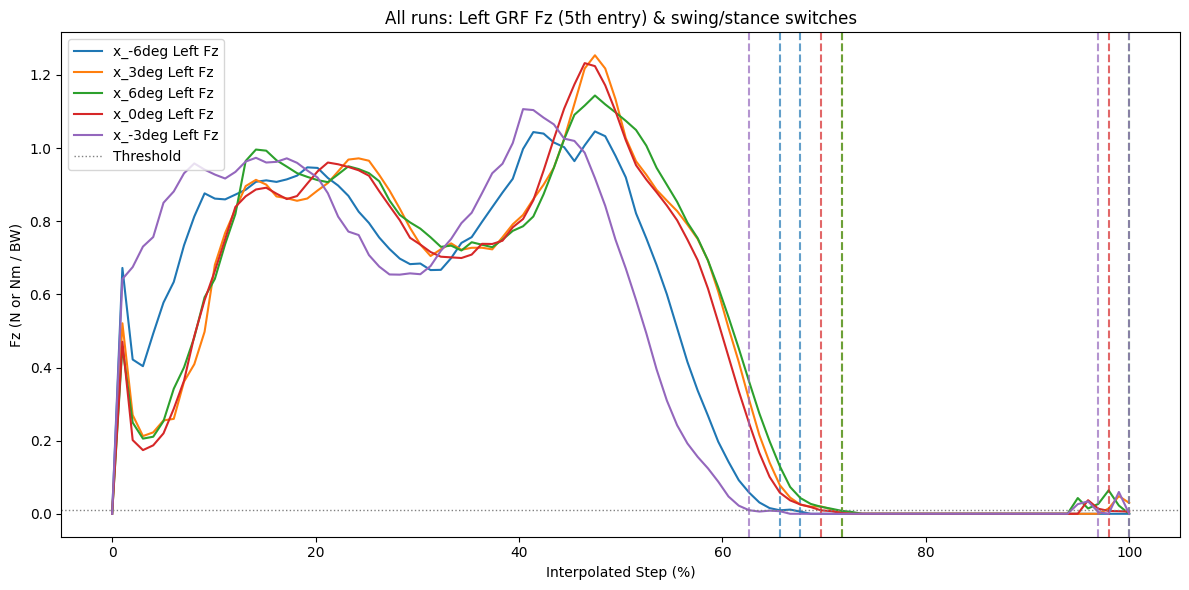

left_switches:  {'x_-6deg': [65, 67], 'x_3deg': [71], 'x_6deg': [71, 99], 'x_0deg': [69, 97], 'x_-3deg': [62, 96, 99]}
right_switches:  {'x_-6deg': [71, 81], 'x_3deg': [67], 'x_6deg': [67], 'x_0deg': [67, 69], 'x_-3deg': [72, 83]}


In [15]:
# Detect and save mean and std of stance to swing phase, determined by the Fz in GRF for left and right foot
# Where mean turns 0 for first time 
importlib.reload(eval_pros)

postprocess_handler = eval_pros.PostProcessMetricsHandler()

left_switches, right_switches = postprocess_handler.plot_grf_Fz_switch_all_runs(
        #grf_components,
        all_loaded_data,
        run_step_data,
        interp_len=100,
        body_weight_to_normalize = 86.6*9.81,
    )

print('left_switches: ', left_switches)
print('right_switches: ', right_switches)

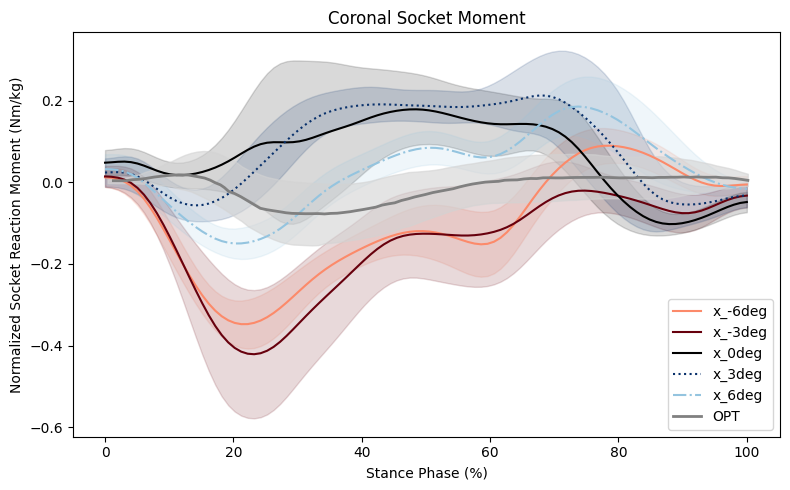

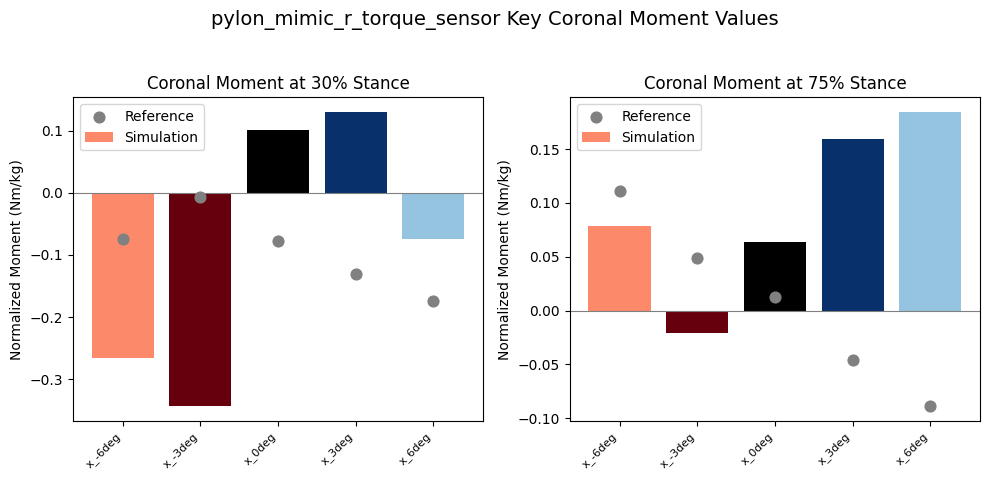

In [17]:
importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()

# sensor_body_names = ['knee'] #['pylon', 'socket']
sensor_body_names = ['pylon', 'socket']

knee_alignment_baseline_file = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Alignment_Data_Schmalz_2002.csv"
knee_alignment_data_mass = 85#*9.81 # std 15

pylon_alignment_baseline_file = "/home/nadinebadie/loco-mujoco/prosthesis_evaluation/Kobayashi_SACH_optimalAlignment_socketMoment_2016.csv"

direction = "x"
postprocess_handler.plot_sensor_force_pylon_all_runs_stance_sorted_flock(all_loaded_data, run_step_data, direction, left_switches, right_switches,folder_name, interp_len=100, 
                                                                         body_weight_to_normalize=86.6, 
                                                                         smooth_data=True, 
                                                                         body_in_sensor_names = sensor_body_names,
                                                                         knee_alignment_baseline_file = knee_alignment_baseline_file, 
                                                                         knee_alignment_data_mass = knee_alignment_data_mass,
                                                                         prosthesis_side = 'left',#'left', 
                                                                         pylon_optimal_alignment_baseline_file = pylon_alignment_baseline_file
                                                                         )


Run: z_-6deg, Sensor: pylon_mimic_r_torque_sensor, Std Median: 0.025, Std Mean: 0.052, Std Max: 0.201, Std Min: 0.001


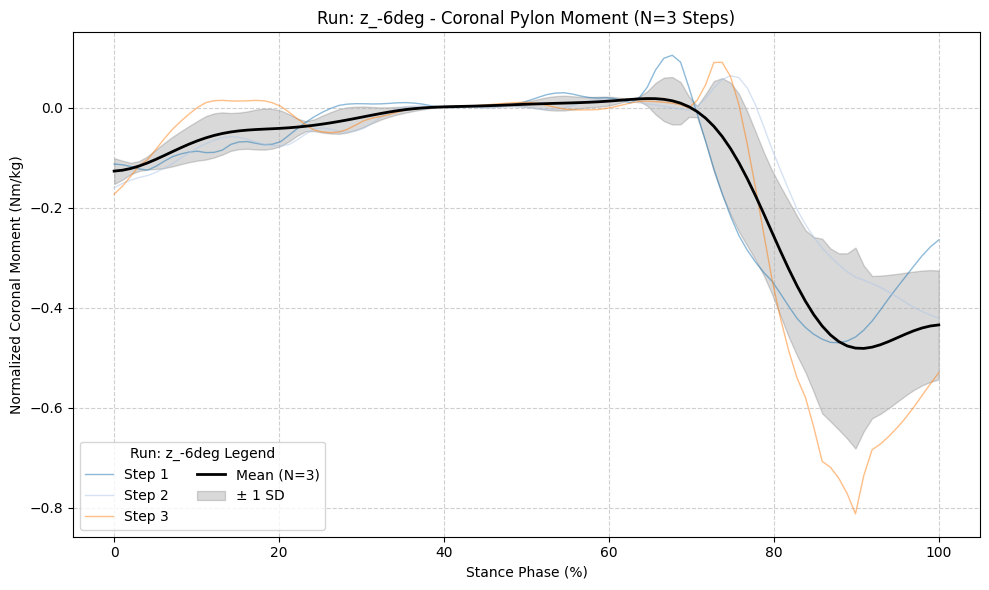

In [52]:
importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()

direction = "x" 
postprocess_handler.plot_sensor_force_pylon_steps_per_run_stance(all_loaded_data, run_step_data, direction, left_switches, right_switches,folder_name, interp_len=100, 
                                                                         body_weight_to_normalize=86.6, 
                                                                         smooth_data=True)

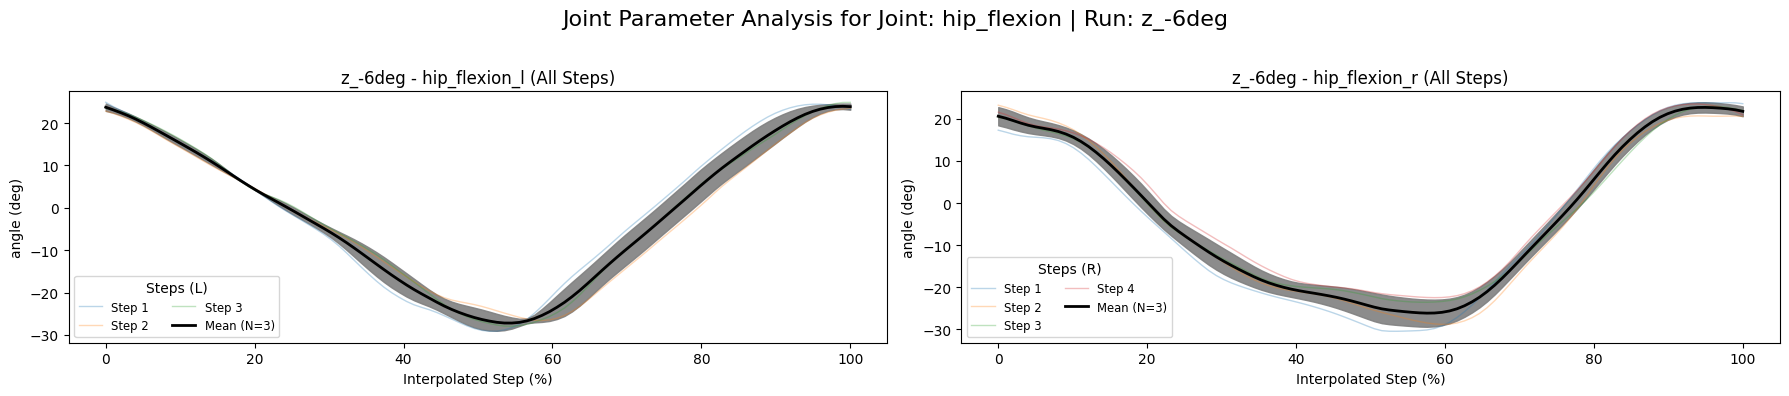

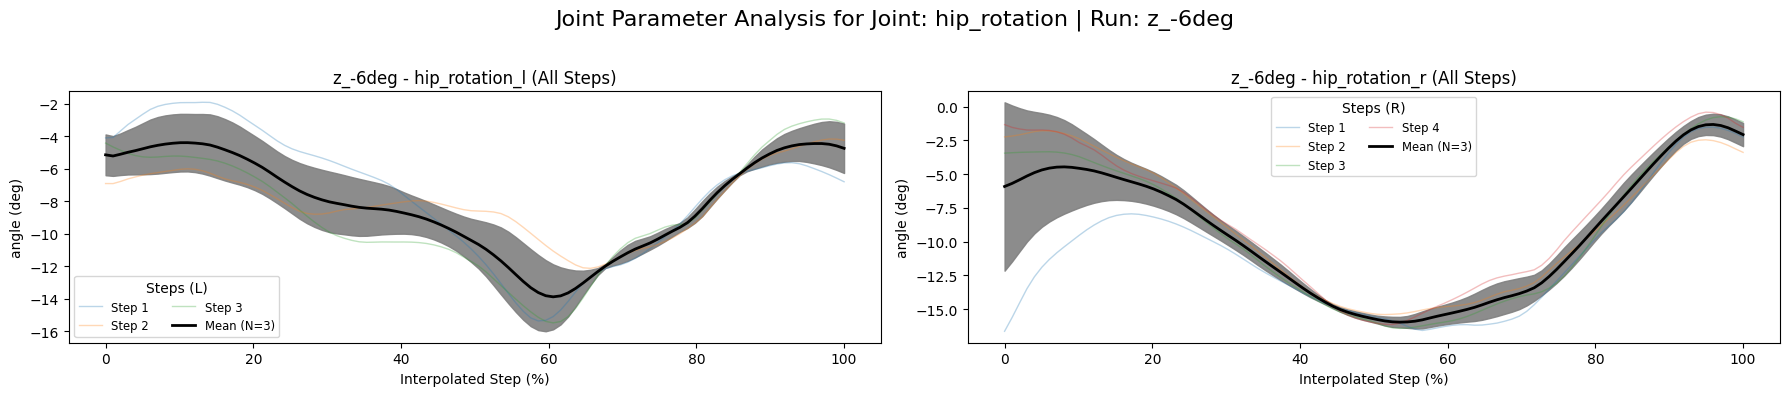

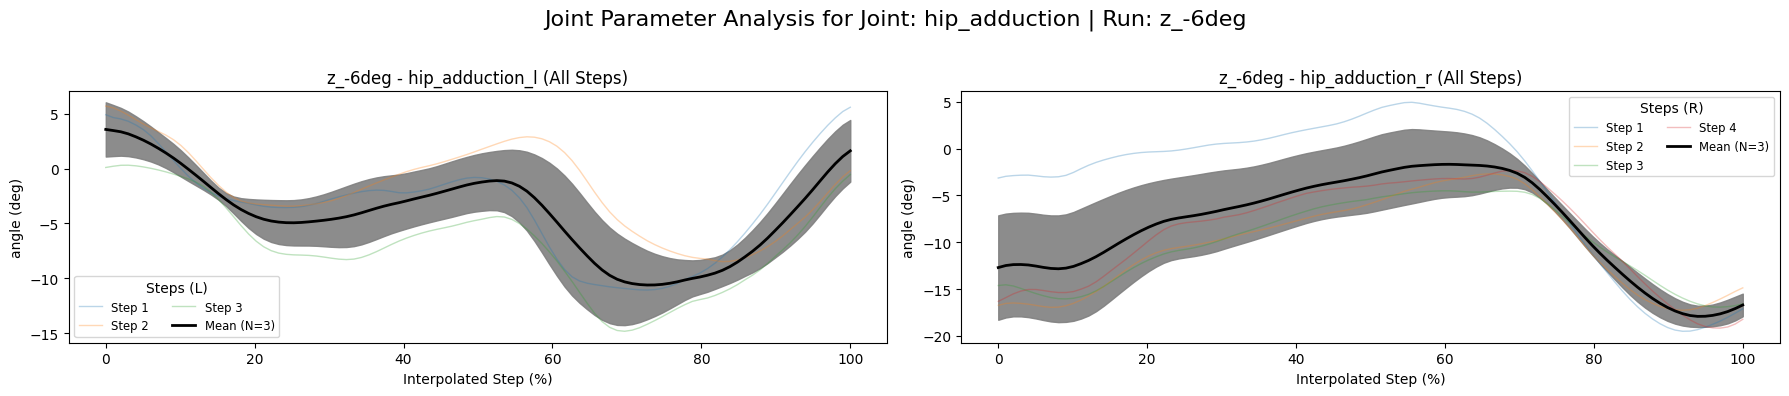

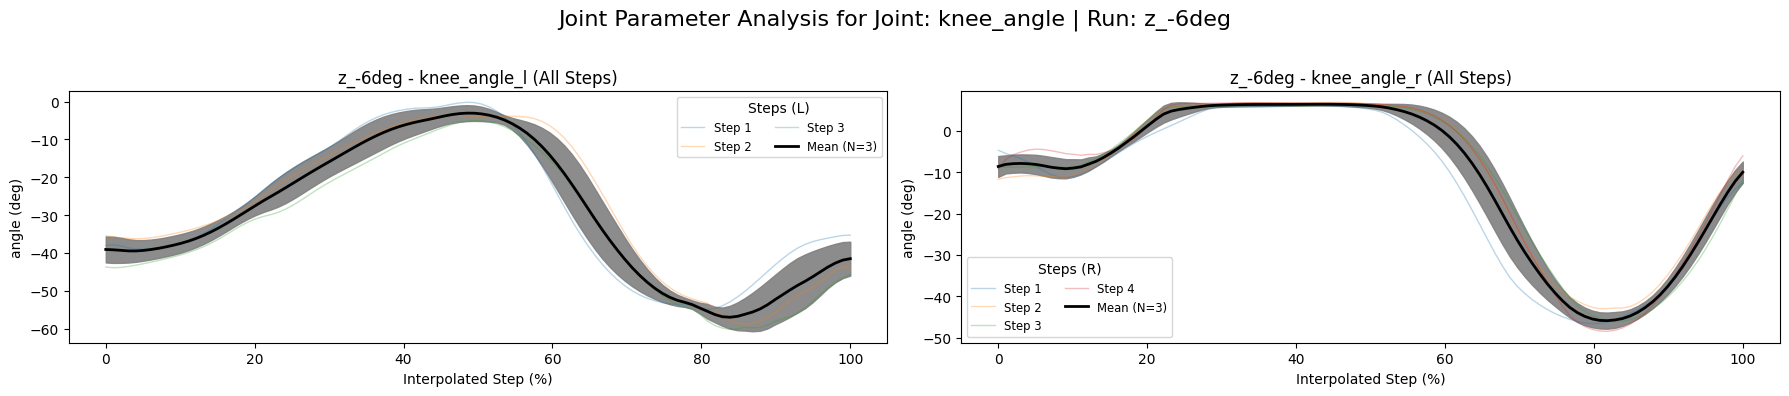

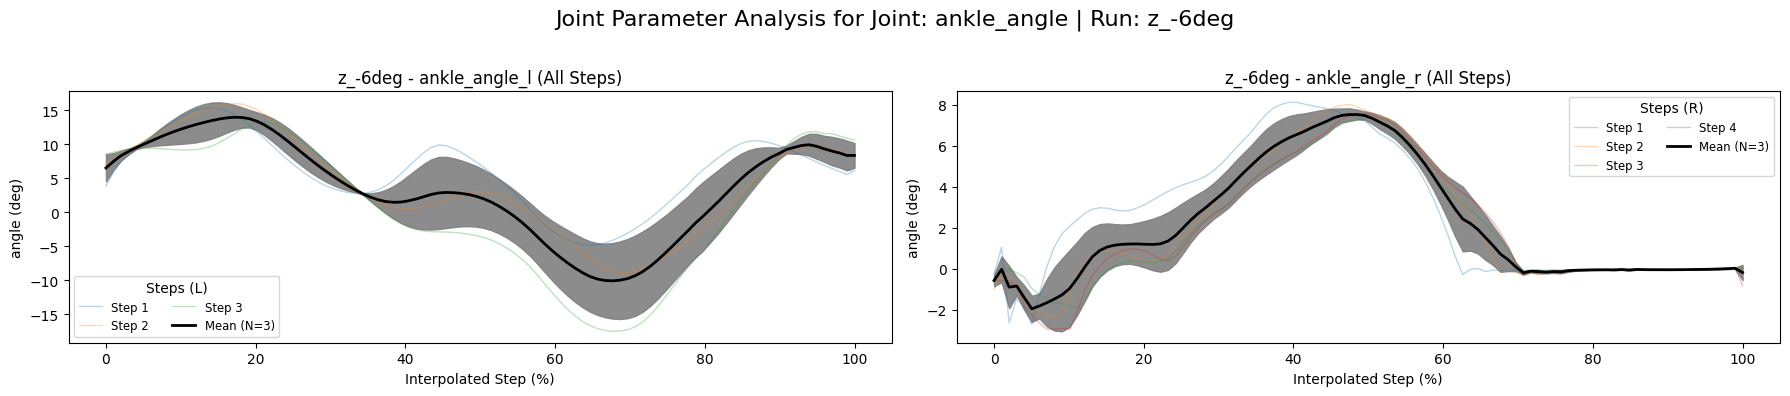

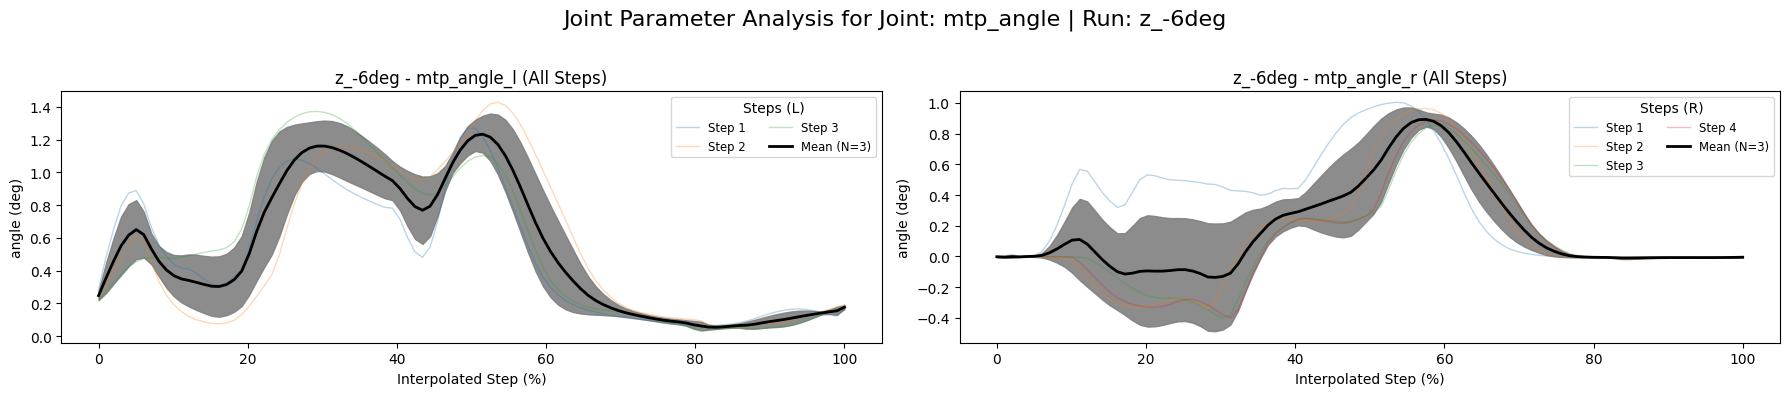

In [59]:
importlib.reload(eval_pros)
postprocess_handler = eval_pros.PostProcessMetricsHandler()

# joint_names_list = [ 'hip_adduction']  #'hip_rotation',# List of joint base names
joint_names_list = ['hip_flexion', 'hip_rotation', 'hip_adduction', 'knee_angle', 'ankle_angle', 'mtp_angle']  #'hip_rotation',# List of joint base names


postprocess_handler.plot_joint_angle_steps_and_mean(
    joint_names_list,
    all_loaded_data,
    run_step_data,
    parameter_name="angle",
    convert_to_deg=True,
    interp_mode="interp",
    interp_len=100,
    plot_baseline=True,
    baseline_data=joint_data_baseline,
) 

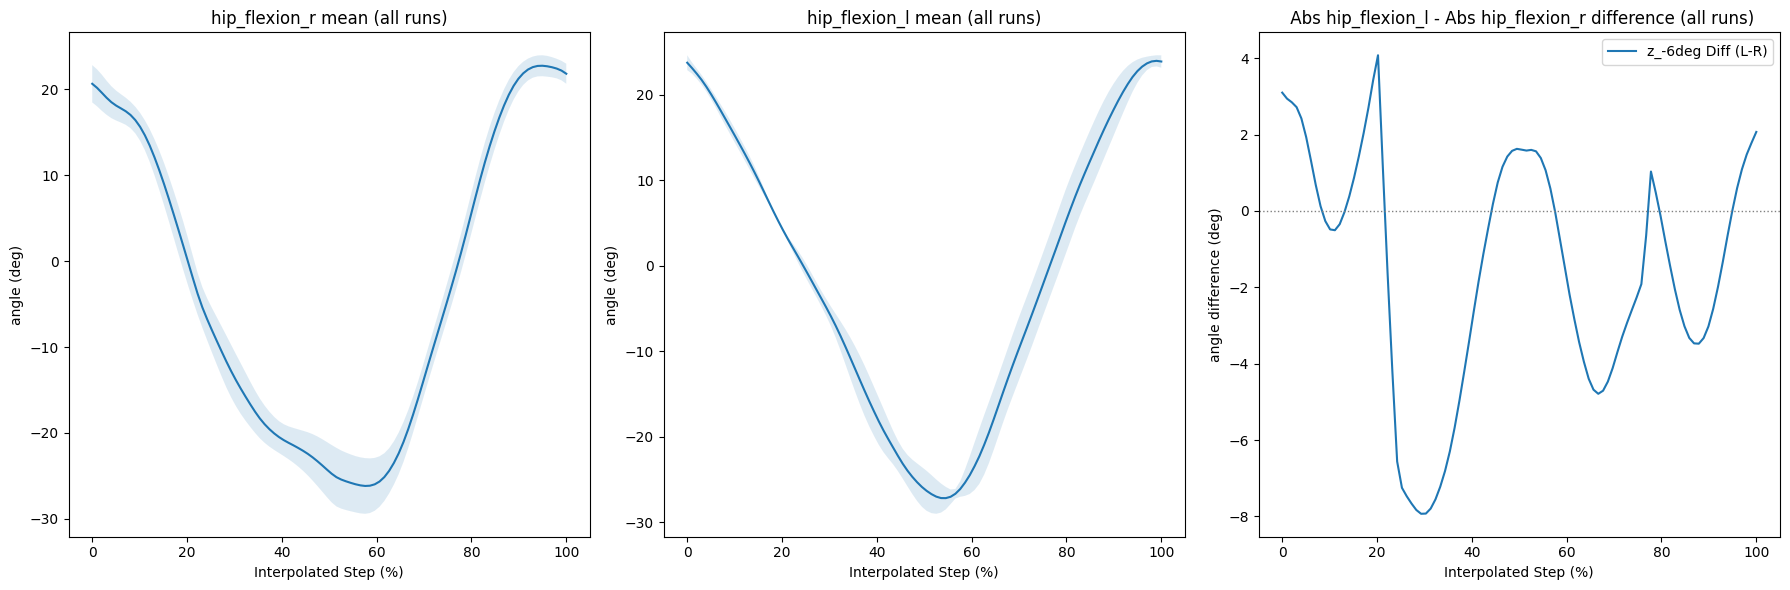

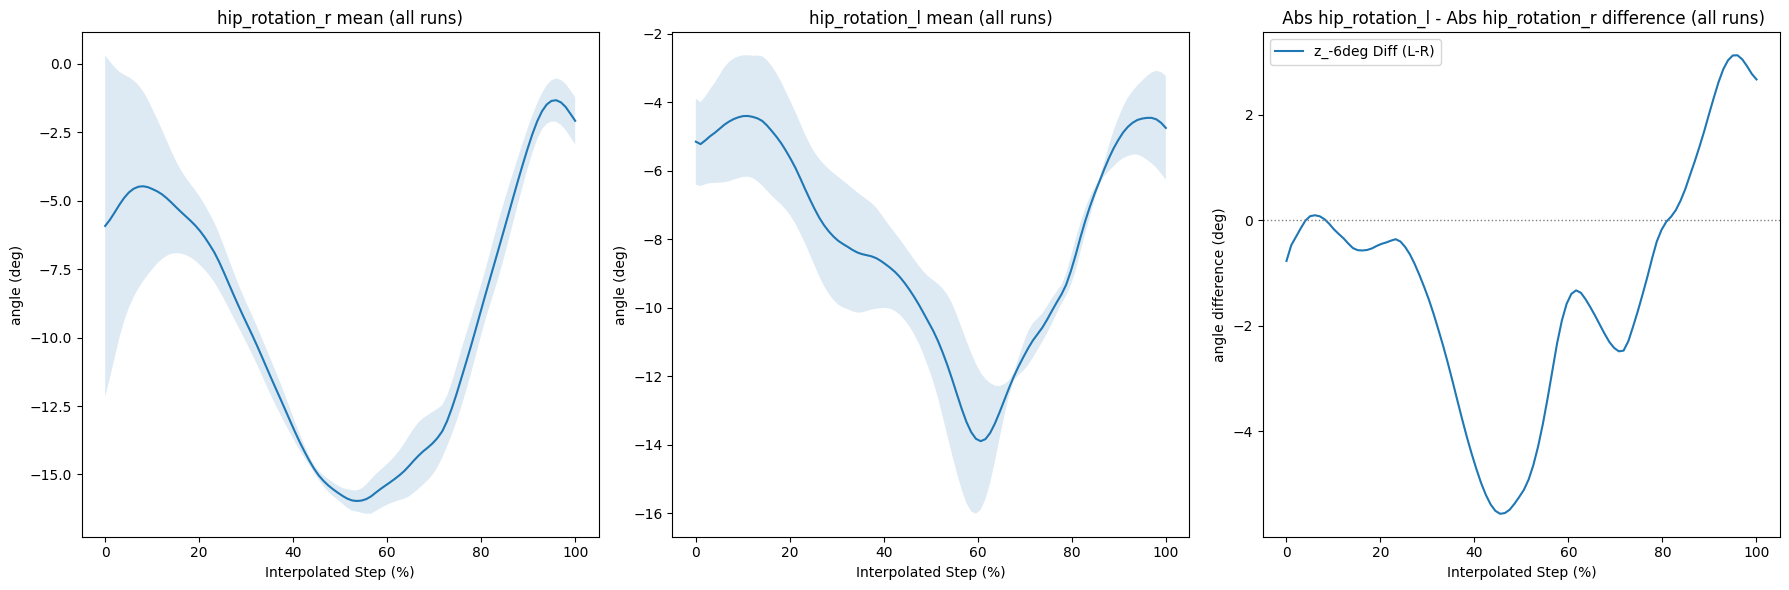

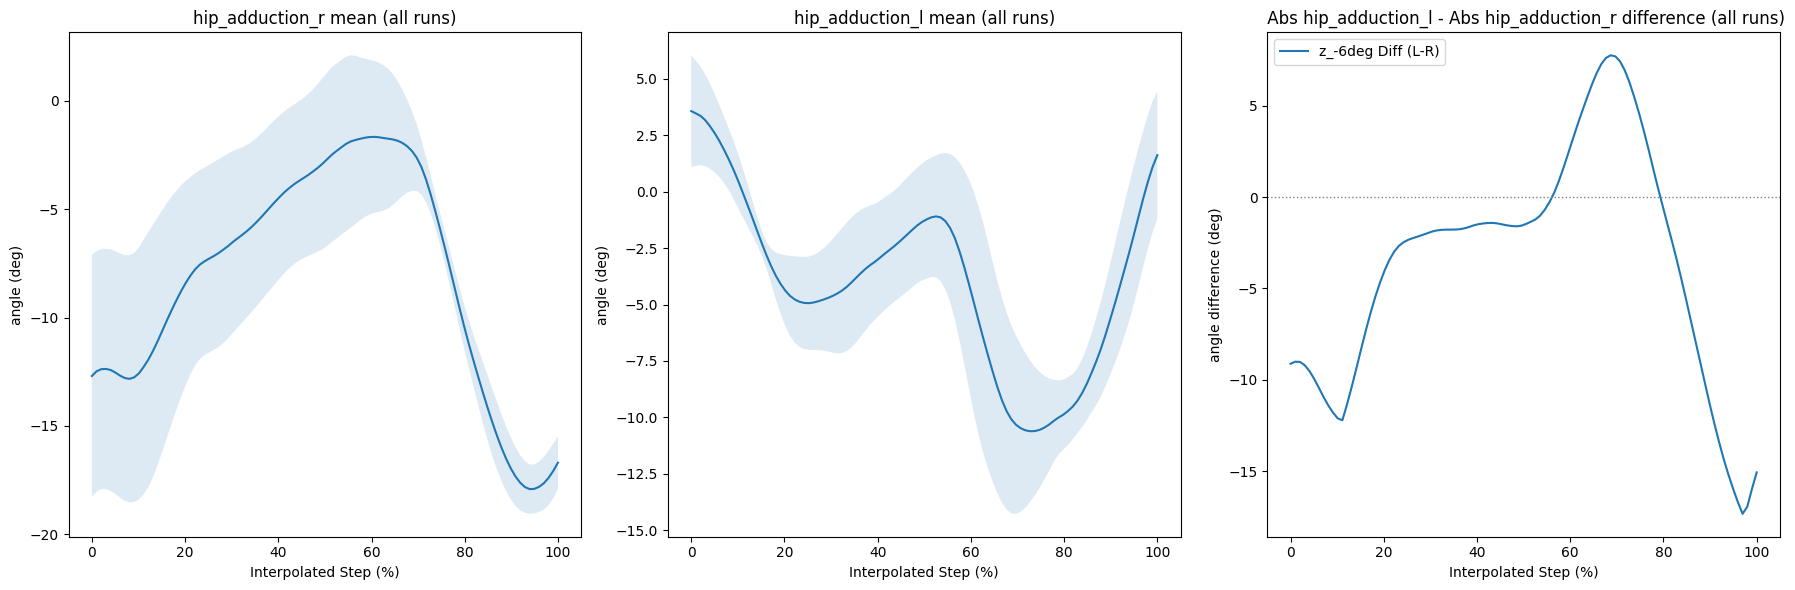

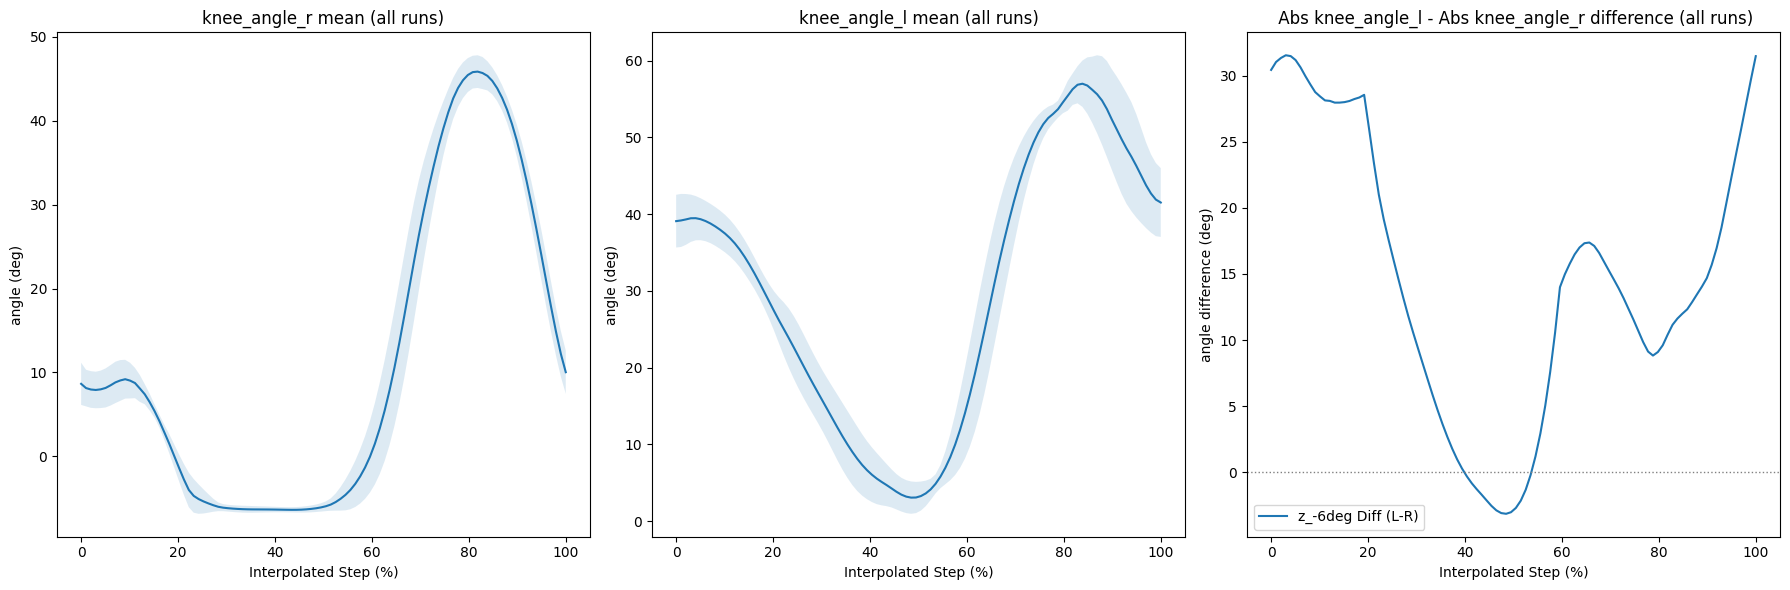

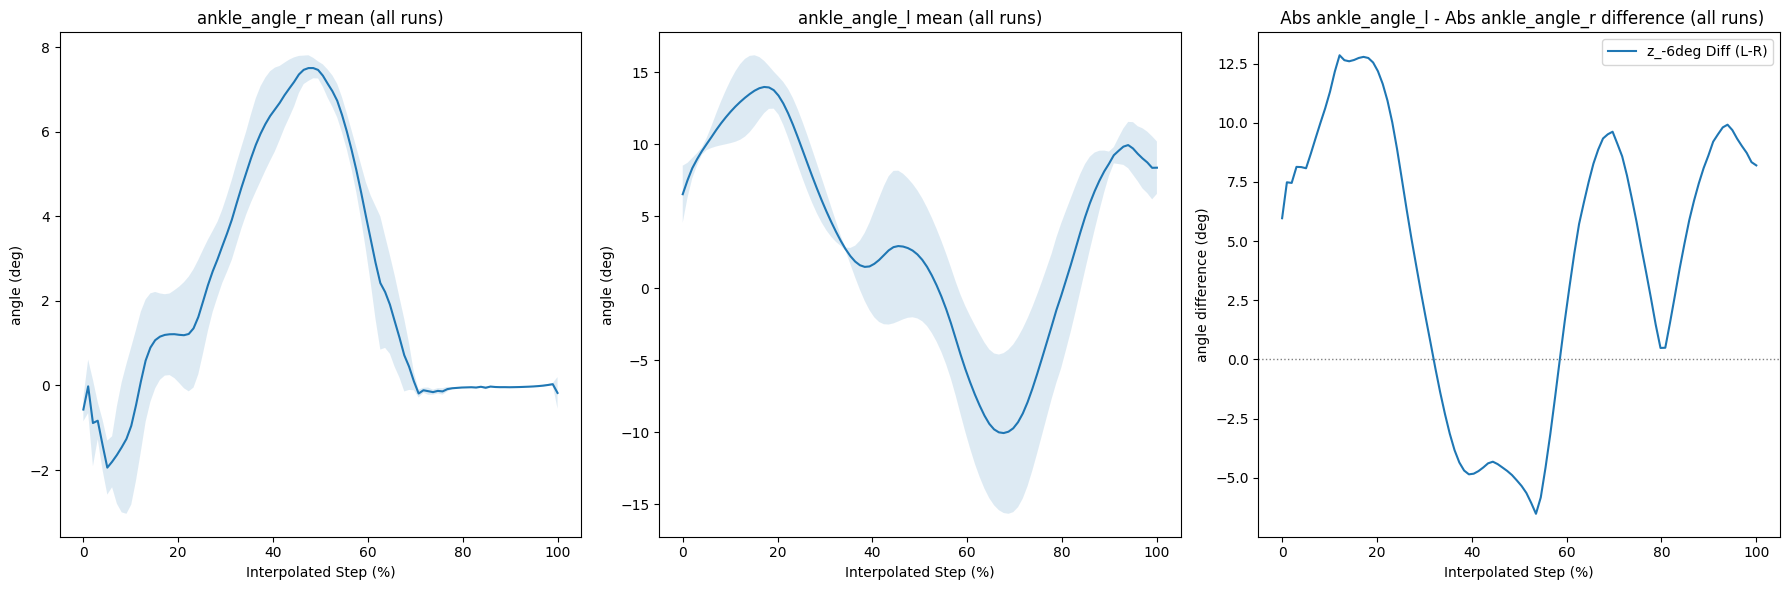

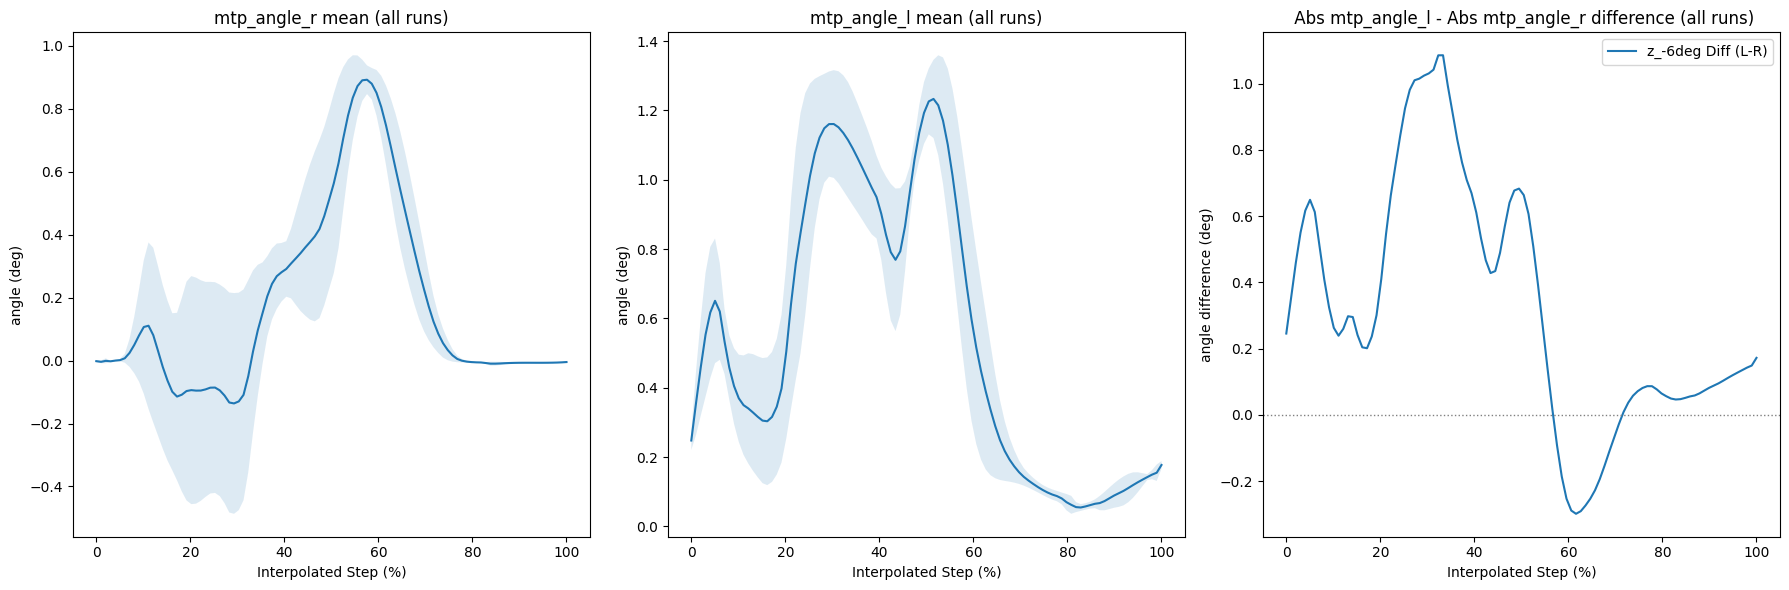

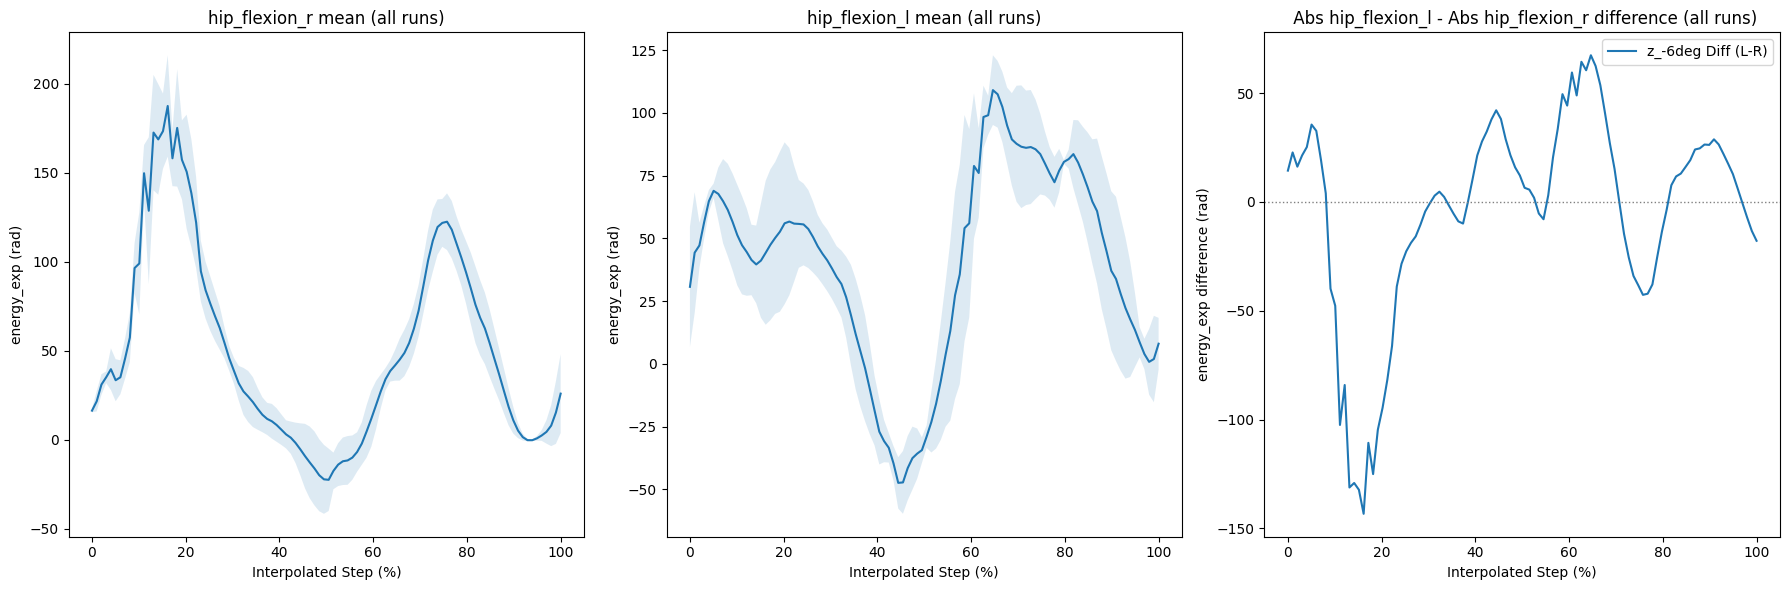

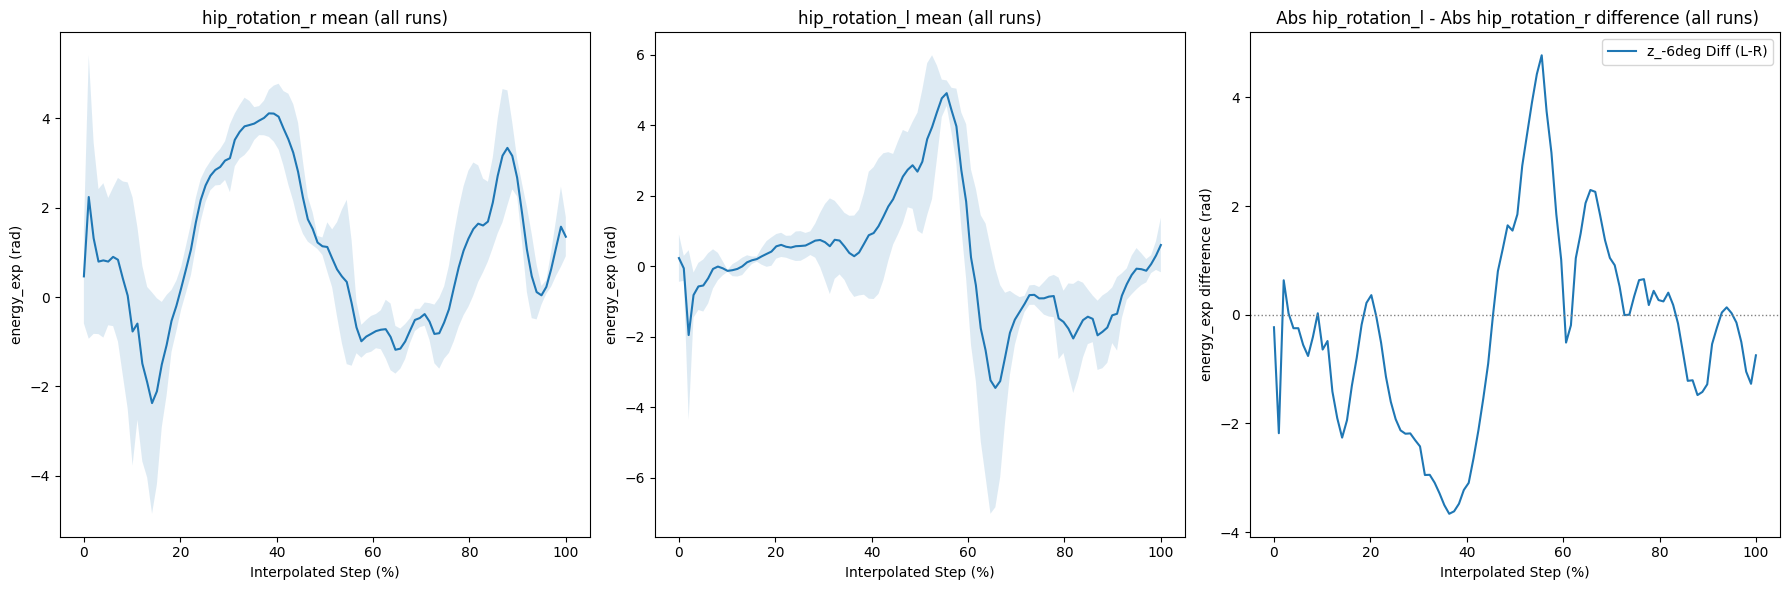

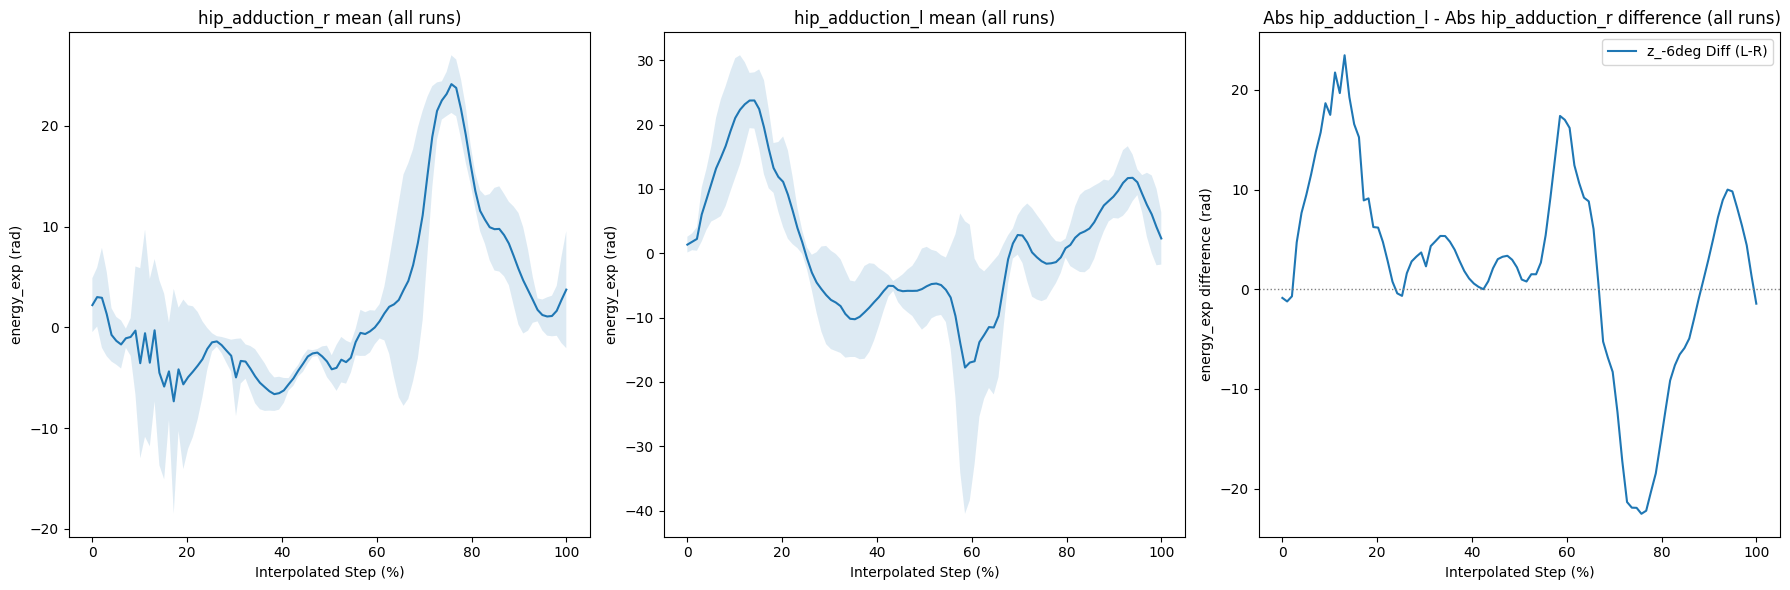

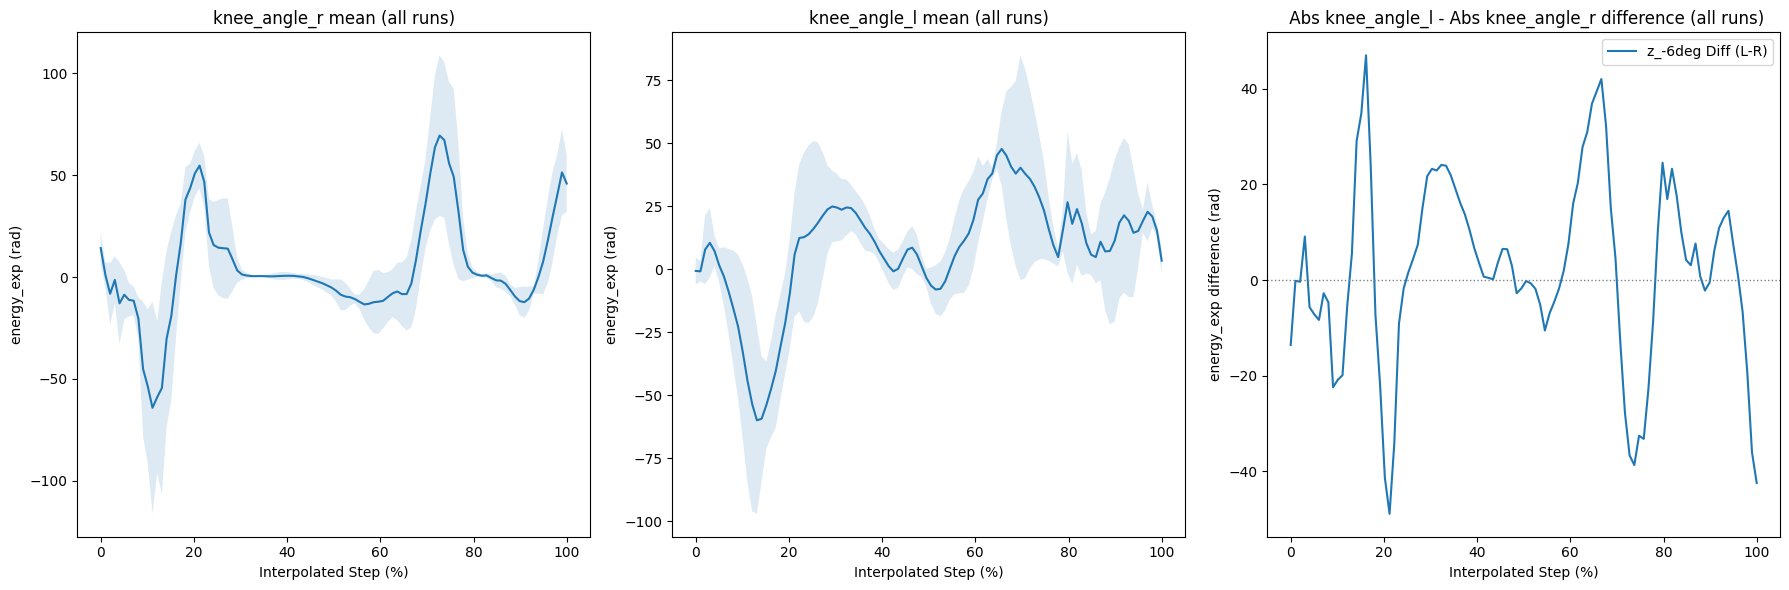

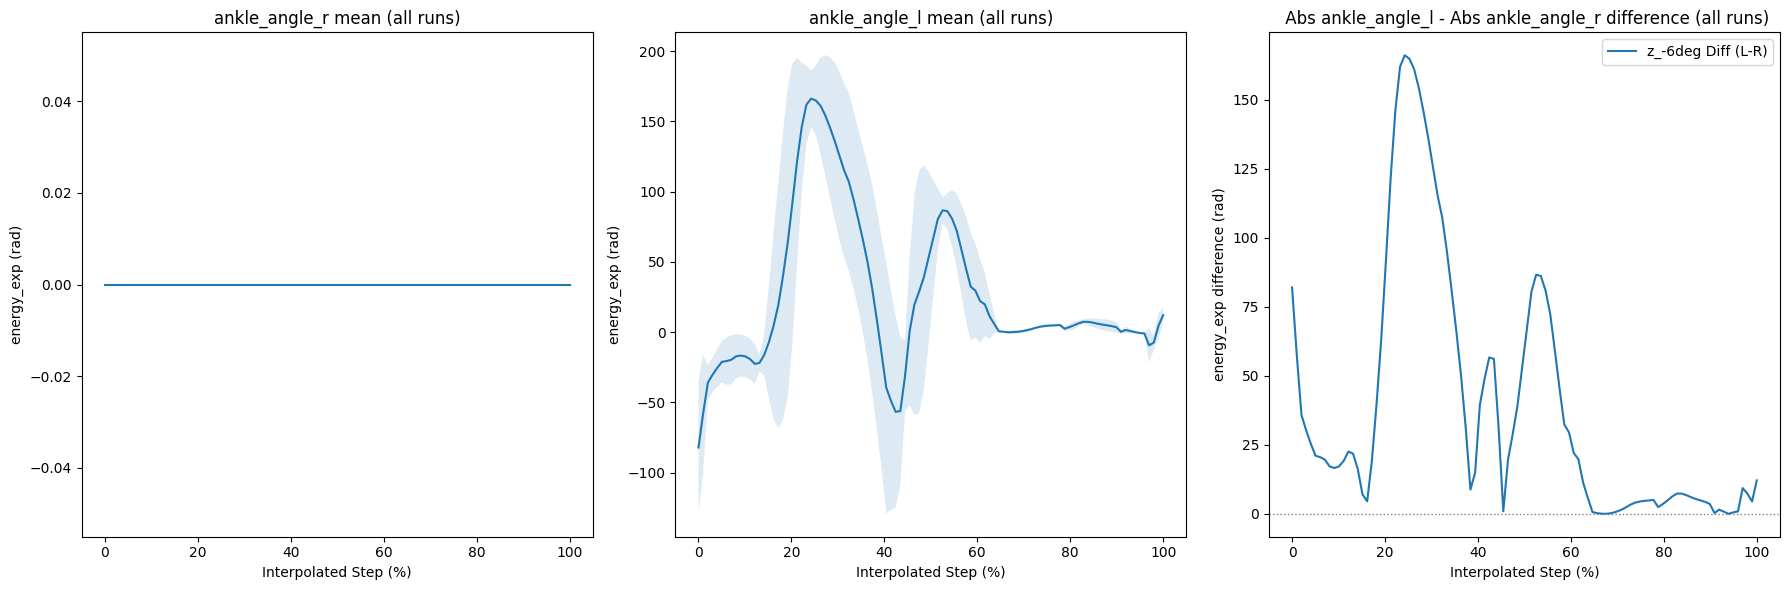

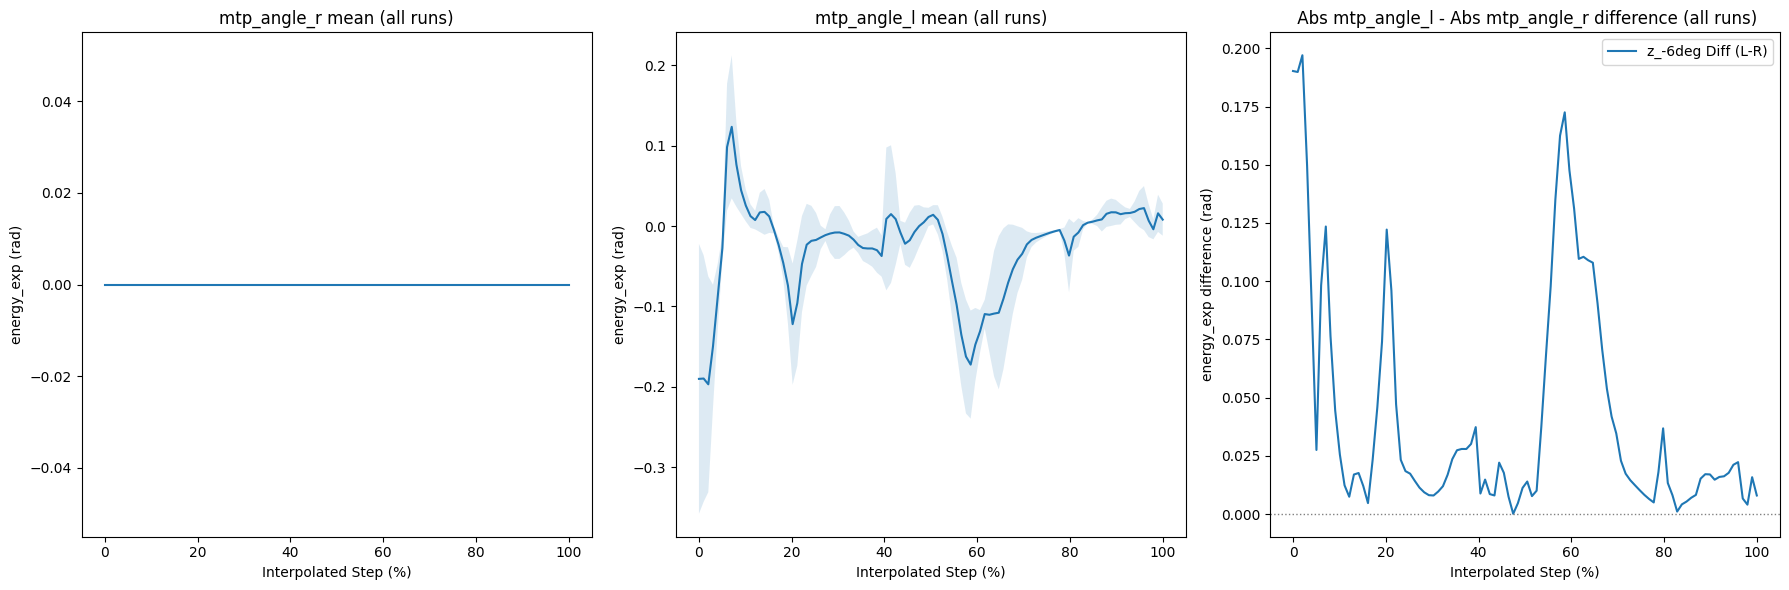

In [58]:
joint_names_list = ['hip_flexion', 'hip_rotation', 'hip_adduction', 'knee_angle', 'ankle_angle', 'mtp_angle'] #'hip_rotation',# List of joint base names

postprocess_handler.plot_joint_angle_symmetry_all_runs(
    joint_names_list,
    all_loaded_data,
    run_step_data,
    parameter_name="angle",
    convert_to_deg=True,
    interp_mode="interp",
    interp_len=100,
)

postprocess_handler.plot_joint_angle_symmetry_all_runs(
    joint_names_list,
    all_loaded_data,
    run_step_data,
    parameter_name="energy_exp",
    convert_to_deg=False,
    interp_mode="interp",
    interp_len=100,
)

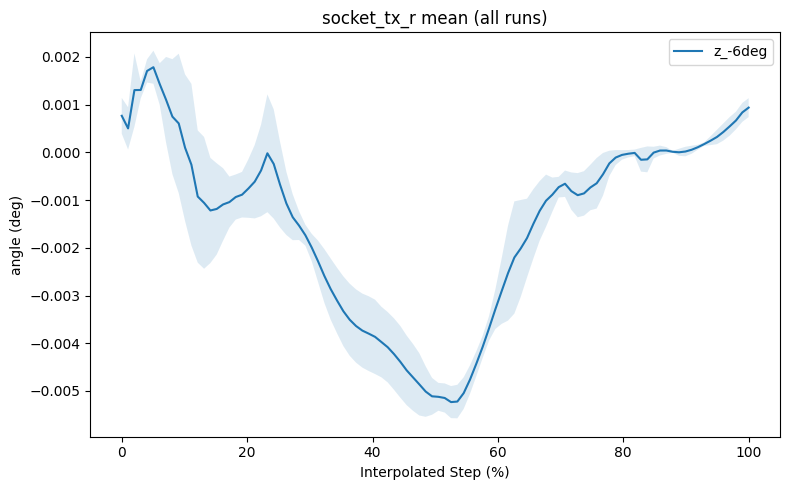

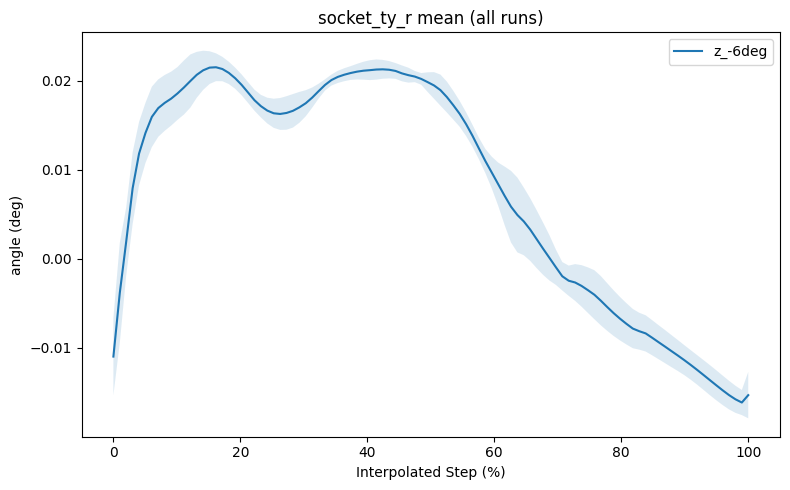

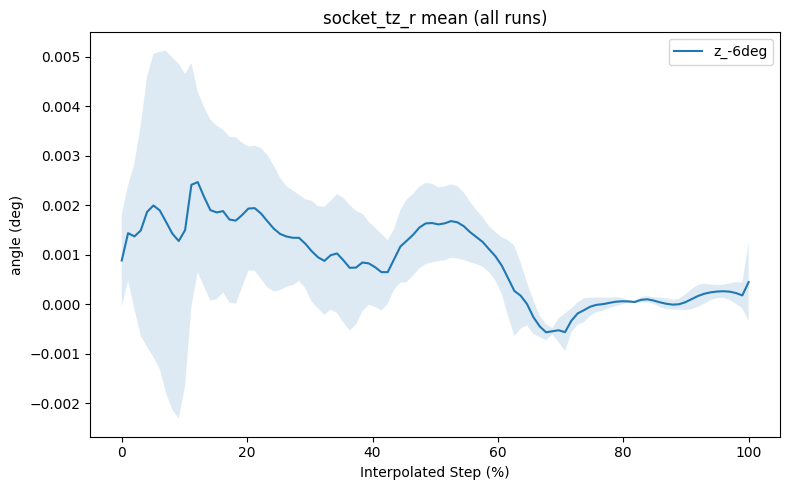

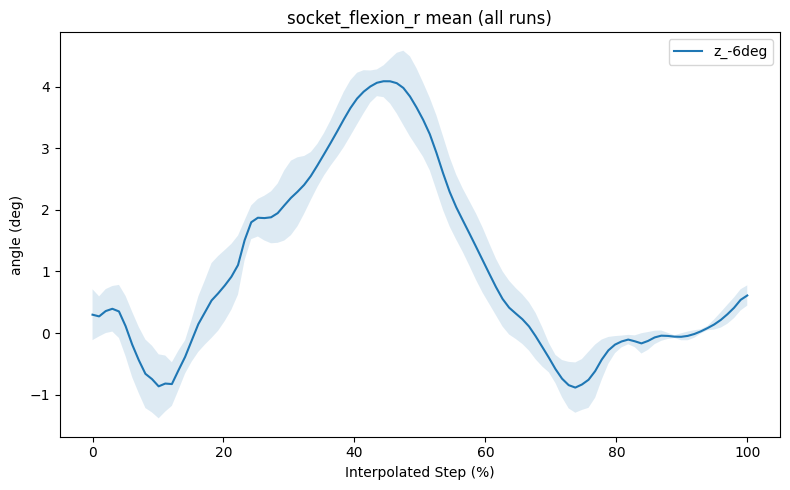

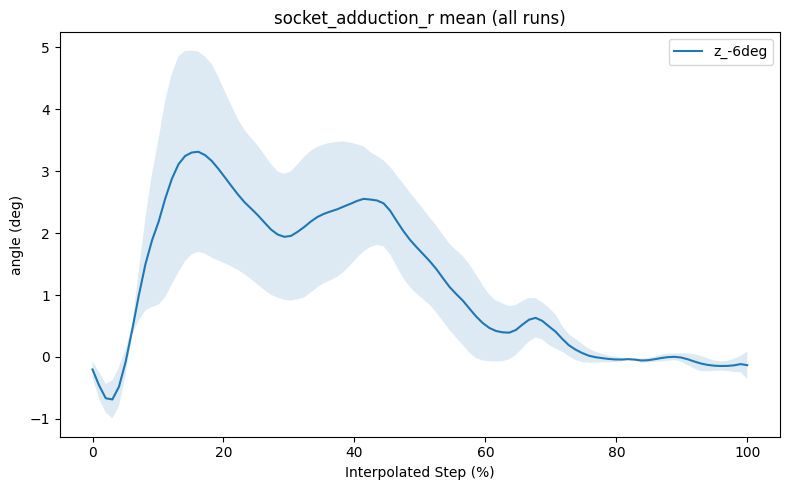

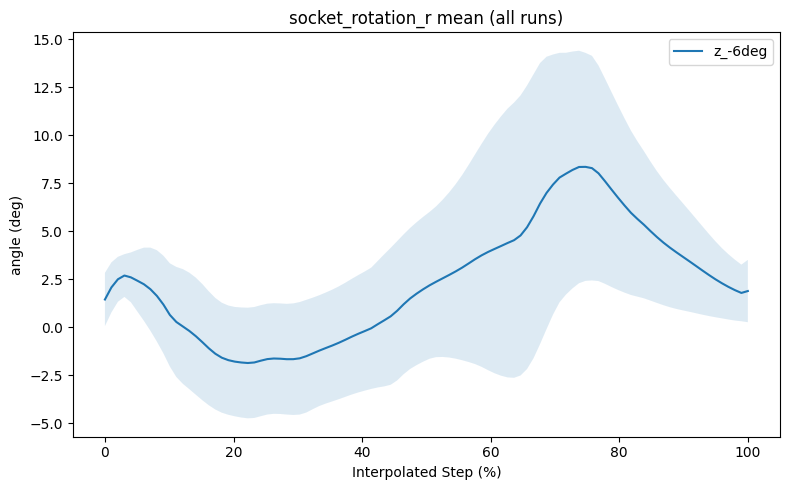

In [57]:
joint_names_list = ['socket_tx', 'socket_ty', 'socket_tz', 'socket_flexion', 'socket_adduction', 'socket_rotation']  #'hip_rotation',# List of joint base names
# plot angle
postprocess_handler.plot_joint_angle_single_side_all_runs(
    joint_names_list,
    all_loaded_data,
    run_step_data,
    parameter_name="angle",
    convert_to_deg=True,
    interp_mode="interp",
    interp_len=100,
    plot_baseline=True,
    baseline_data=joint_data_baseline,
    side='right',
)   


left_std None
right_std None


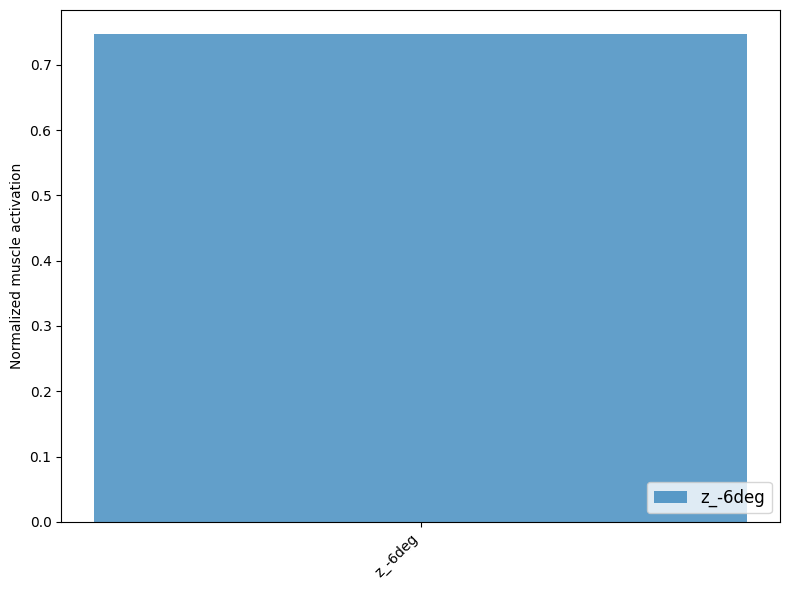

Number of muscles in 'all_muscles': 46
std_matrix [nan]


In [54]:
# Calculate and plot the muscle activations for right and left summed up together
# Bar plot sum along all steps and muscles data for all muscles and all parameters (sum left+right for each muscle group)
# The user's code starts here, with necessary adjustments.
n_steps = 1000

all_run_keys = list(all_loaded_data.keys())

# Get only the 'all_muscles' group
all_muscle_groups = ['all_muscles']

# Get number of muscles for the 'all_muscles' group
n_musc = {}
if all_run_keys:
    run_dict = all_loaded_data[all_run_keys[0]]
    eval_muscle_names = run_dict.get("evaluation_muscle_names", {})
    # This assumes 'all_muscles' is a key in evaluation_muscle_names
    n_musc['all_muscles'] = len(eval_muscle_names.get('all_muscles', []))

# Bar plot for 'all_muscles' activation
sum_matrix = []
std_matrix = []
for run_key in all_run_keys:
    run_dict = all_loaded_data[run_key]
    act = run_dict.get("step_num_norm_activations") #"sum_muscles_activations")
    
    # Process 'all_muscles' data
    left = act.get("all_muscles_left") if act else None
    right = act.get("all_muscles_right") if act else None
    left_std = act.get("all_muscles_left_std") if act else None
    right_std = act.get("all_muscles_right_std") if act else None
    
    # Convert to scalar, if necessary
    if isinstance(left, tuple): left = left[0]
    if hasattr(left, "item"): left = left.item()
    if isinstance(right, tuple): right = right[0]
    if hasattr(right, "item"): right = right.item()

    # Sum left and right activations
    total_sum = (left if left is not None else 0) + (right if right is not None else 0)
    print('left_std', left_std)
    print('right_std', right_std)
    # Compute std (sqrt of sum of variances)
    if left_std is not None and right_std is not None:
        # print('left_std', left_std)
        # print('right_std', right_std)
        total_std = np.sqrt(left_std**2 + right_std**2)
    elif left_std is not None:
        total_std = left_std
    elif right_std is not None:
        total_std = right_std
    else:
        total_std = np.nan
        
    sum_matrix.append(total_sum if (left is not None or right is not None) else np.nan)
    std_matrix.append(total_std)

# Normalize by the number of muscles and n_steps
num_muscles = n_musc.get('all_muscles', 1)
sum_matrix = np.array(sum_matrix) #/ (num_muscles * n_steps)
std_matrix = np.array(std_matrix) #/ (num_muscles * n_steps)

# Plotting
bar_width = 0.5
x = np.arange(len(all_run_keys))
plt.figure(figsize=(8, 6))

for i, run_key in enumerate(all_run_keys):

    bar = plt.bar(x[i], sum_matrix[i], width=bar_width, label=run_key, alpha=0.7)
    
    # Add error bar for std
    mean = sum_matrix[i]
    std = std_matrix[i]
    if not np.isnan(mean) and not np.isnan(std):
        plt.errorbar(x[i], mean, yerr=std, color='black', capsize=5, fmt='none', ecolor='black')

plt.xticks(x, all_run_keys, rotation=45, ha='right')
plt.ylabel("Normalized muscle activation")
# plt.title("Normalized Activations for 'all_muscles' (Mean ± Std)")
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

# Print the number of muscles in 'all_muscles' group
print("Number of muscles in 'all_muscles':", n_musc.get('all_muscles'))
print('std_matrix', std_matrix)